# Multi-Architecture Vision Transformer Benchmark for Particle Collision Images

**GSoC ML4SCI Project** -- Research-Grade Experimental Framework

This notebook benchmarks four Vision Transformer architectures on particle collision detector images:
1. **Standard ViT** -- quadratic self-attention O(N^2*d)
2. **Linear Attention ViT** -- ReLU kernel feature maps, O(N*d^2) linear complexity
3. **L2ViT** -- Linear Global Attention + Local Window Attention (hybrid)
4. **XCiT ViT** -- Cross-Covariance Attention O(N*d^2)

Architecture diagrams: `../images/`

---

### Changelog (v2 – Stability & Metrics Update)

| Change | Why |
|--------|-----|
| `STRICT_DETERMINISM = False` default | Avoids CUBLAS workspace errors on Windows/Jupyter without kernel restart |
| DataLoader `num_workers=0`, `pin_memory=False` | Prevents multiprocessing hangs in notebook/Windows environments |
| Early stopping on **val macro-F1** | Directly optimises the metric we care about for classification quality |
| Checkpoint best model by **macro-F1** (tie-break: lower MAE) | Saves the model that balances classification and regression |
| Gradient clipping (max_norm=1.0) | Already present; confirmed across all pipelines |
| AMP default **OFF** in notebook | Avoids dtype instability; toggle `USE_AMP=True` for GPU speedup |
| Optional EMA (default OFF) | Smooths weights for better generalisation; toggle `USE_EMA=True` |
| `lambda_reg` sweep & Huber loss toggle | Fine-tune classification/regression trade-off |
| Two-phase training option (OFF by default) | Warm up classification head before adding regression objective |
| Balanced Accuracy, ROC-AUC, PR-AUC, ECE added | Richer evaluation for imbalanced or calibration-sensitive tasks |
| Multi-seed runner (seeds 42, 52, 62) | Report mean ± std for robust benchmarking |
| Quick debug mode (`RUN_MODE="debug"`) | 2-epoch sanity check; set `RUN_MODE="full"` for real experiments |

**How to run:**
- **Quick sanity test:** Set `RUN_MODE = "debug"` in Section 1, then Run All.
- **Full benchmark:** Set `RUN_MODE = "full"`, then Run All.
- **3-seed summary:** After full run, execute Section 17 (Multi-Seed Runner).


## Section 1: Configuration

In [1]:
# ============================================================
# Section 1: Configuration
# All hyperparameters in one place for reproducibility
# ============================================================
#
# --- v2 changes ---
# • Added STRICT_DETERMINISM toggle (default False)
# • Added RUN_MODE ("debug" / "full") for quick sanity vs full run
# • Added USE_AMP, USE_EMA toggles (both default False for notebook stability)
# • Added LAMBDA_REG, USE_HUBER_LOSS, TWO_PHASE_TRAINING config
# • Added SWEEP_CONFIGS for mini hyperparameter sweep
# • DataLoader defaults: num_workers=0, pin_memory=False
# ============================================================

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Run mode: "full" (production training) or "debug" (2 epochs, fast sanity check)
# ----------------------------------------------------------
RUN_MODE = "full"

# ----------------------------------------------------------
# Determinism control
# ----------------------------------------------------------
# STRICT_DETERMINISM = True requires:
#   - Setting env var CUBLAS_WORKSPACE_CONFIG=:4096:8 BEFORE launching Python
#   - A kernel restart after changing this flag
# Default False avoids CUBLAS workspace errors on Windows / Jupyter.
STRICT_DETERMINISM = False

# ----------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------

# Model
IMG_SIZE = 64          # Input image resolution
PATCH_SIZE = 8         # Patch size for tokenization
IN_CHANS = 8           # Number of input channels (detector layers)
EMBED_DIM = 256        # Transformer embedding dimension
DEPTH = 10             # Number of transformer blocks
NUM_HEADS = 8          # Number of attention heads
MLP_RATIO = 4.0        # MLP hidden dim ratio
DROPOUT = 0.1          # Dropout probability

# Training
BATCH_SIZE = 32
EPOCHS = 35
LR = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_FRAC = 0.80      # 80/20 train/val split
SEED = 42
LAMBDA_REG = 0.2       # Weight for regression loss (was 1.0; 0.2 focuses on classification)
REGRESSION_LAMBDA = LAMBDA_REG  # backward compat alias
GRAD_CLIP_NORM = 1.0   # Max gradient norm for clipping

# Loss options
USE_HUBER_LOSS = False  # True = SmoothL1 (Huber) for mass regression; False = MSE

# AMP & EMA
USE_AMP = False         # Set True for GPU speed-up (may cause dtype issues in notebook)
USE_EMA = False         # Exponential Moving Average of model weights

# Early stopping
ES_PATIENCE = 7         # Patience for early stopping on val macro-F1

# Two-phase training (OFF by default)
TWO_PHASE_TRAINING = False
PHASE_A_EPOCHS = 5      # classification-focused warmup epochs (lambda_reg ≈ 0)
PHASE_A_LAMBDA = 0.0    # regression weight during Phase A

# Logging
LOG_EVERY_N_BATCHES = 50  # Print batch progress every N batches (0 = off)

# Pretraining (MAE-style, not used in benchmark but kept for reference)
PRETRAIN_EPOCHS = 20
MASK_RATIO = 0.50
LR_PRETRAIN = 1e-3

# Data paths
DATA_DIR = Path(r"C:\Users\Rahul\Desktop\AA Gsoc'26\data")
UNLABELED_FILE = DATA_DIR / "Dataset_Specific_Unlabelled.h5"
LABELED_FILE = DATA_DIR / "Dataset_Specific_labelled_full_only_for_2i.h5"

NUM_CLASSES = 2  # quark vs gluon (or whatever the dataset has)

# ----------------------------------------------------------
# DataLoader defaults (stability in Jupyter / Windows)
# ----------------------------------------------------------
DL_NUM_WORKERS = 0
DL_PIN_MEMORY = False

# ----------------------------------------------------------
# Sweep configuration (Section 17 mini-sweep)
# ----------------------------------------------------------
SWEEP_CONFIGS = {
    "lr": [1e-4, 3e-4, 5e-4],
    "weight_decay": [1e-5, 1e-4],
    "lambda_reg": [0.1, 0.2, 0.3],
    "dropout": [0.1, 0.2],
}

# ----------------------------------------------------------
# Multi-seed runner seeds
# ----------------------------------------------------------
MULTI_SEEDS = [42, 52, 62]

# ----------------------------------------------------------
# Device detection
# ----------------------------------------------------------

def get_device() -> torch.device:
    """Auto-detect the best available compute device."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Using device: {DEVICE}", flush=True)
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}", flush=True)
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB", flush=True)


# ----------------------------------------------------------
# Reproducibility — seed everything
# ----------------------------------------------------------

def seed_everything(seed: int = 42) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if STRICT_DETERMINISM:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.use_deterministic_algorithms(False)


seed_everything(SEED)
print(f"Seeds set to {SEED} | STRICT_DETERMINISM={STRICT_DETERMINISM}", flush=True)
print(f"RUN_MODE={RUN_MODE} | EPOCHS={EPOCHS} | PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}", flush=True)
print(f"BATCH_SIZE={BATCH_SIZE} | LR={LR} | WEIGHT_DECAY={WEIGHT_DECAY}", flush=True)
print(f"LAMBDA_REG={LAMBDA_REG} | USE_AMP={USE_AMP} | USE_EMA={USE_EMA}", flush=True)
print(f"PyTorch version: {torch.__version__}", flush=True)

# ----------------------------------------------------------
# Optional debug override (uncomment ONLY for quick sanity checks)
# ----------------------------------------------------------
# RUN_MODE = "debug"
# EPOCHS = 2
# PRETRAIN_EPOCHS = 2


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.4 GB
Seeds set to 42
PyTorch version: 2.3.0+cu121


## Section 2: Dataset Loading

In [14]:
# ============================================================
# Section 2: Dataset Loading (HDF5 ONLY, no synthetic fallback)
# ============================================================

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset


def inspect_hdf5(filepath: str) -> None:
    """Print HDF5 structure, shapes, dtypes, and sample unique values for 1D datasets."""
    print(f"\n=== HDF5 File: {filepath} ===")
    with h5py.File(filepath, "r") as f:
        def _print_tree(name, obj):
            indent = "  " * name.count("/")
            if hasattr(obj, "shape"):
                msg = f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}"
                if len(obj.shape) == 1 and obj.shape[0] > 0:
                    sample = np.asarray(obj[: min(50, obj.shape[0])]).reshape(-1)
                    msg += f", sample_unique={np.unique(sample)}"
                print(msg)
            else:
                print(f"{indent}{name}/")
        f.visititems(_print_tree)


class LazyHDF5Dataset(Dataset):
    """
    Lazy-loading HDF5 dataset for particle collision images.
    Requires valid keys for labeled data (mass + label).
    """

    def __init__(
        self,
        filepath,
        labeled: bool = True,
        transform=None,
        img_key: str = None,
        mass_key: str = None,
        label_key: str = None,
    ):
        self.filepath = str(filepath)
        self.labeled = labeled
        self.transform = transform
        self._file = None  # lazy handle

        with h5py.File(self.filepath, "r") as f:
            keys = list(f.keys())

            # -----------------------
            # Resolve image key
            # -----------------------
            if img_key is not None:
                if img_key not in keys:
                    raise ValueError(f"img_key='{img_key}' not found. Available keys: {keys}")
                self.img_key = img_key
            else:
                preferred_img = ["jet", "X", "images", "image", "data", "X_jets", "jet_images", "jets"]
                self.img_key = None
                for k in preferred_img:
                    if k in keys and hasattr(f[k], "shape") and len(f[k].shape) >= 3:
                        self.img_key = k
                        break
                if self.img_key is None:
                    for k in keys:
                        obj = f[k]
                        if hasattr(obj, "shape") and len(obj.shape) >= 3 and obj.shape[0] > 1:
                            self.img_key = k
                            break
                if self.img_key is None:
                    raise ValueError(f"No image-like key found in {self.filepath}. Keys={keys}")

            self.length = int(f[self.img_key].shape[0])

            # -----------------------
            # Resolve labeled keys
            # -----------------------
            self.mass_key = None
            self.label_key = None

            if self.labeled:
                # mass key
                if mass_key is not None:
                    if mass_key not in keys:
                        raise ValueError(f"mass_key='{mass_key}' not found. Available keys: {keys}")
                    self.mass_key = mass_key
                else:
                    for k in ["m", "mass", "m0", "y_mass", "target_mass"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.mass_key = k
                            break
                    if self.mass_key is None:
                        raise ValueError(
                            f"Could not infer mass_key. Please pass it explicitly. Available keys: {keys}"
                        )

                # label key
                if label_key is not None:
                    if label_key not in keys:
                        raise ValueError(f"label_key='{label_key}' not found. Available keys: {keys}")
                    self.label_key = label_key
                else:
                    for k in ["label", "labels", "y", "cls", "class", "target", "pid"]:
                        if k in keys and len(f[k].shape) == 1 and f[k].shape[0] == self.length:
                            self.label_key = k
                            break
                    if self.label_key is None:
                        # fallback: integer-like 1D key with matching length (excluding mass)
                        for k in keys:
                            if k == self.mass_key:
                                continue
                            obj = f[k]
                            if hasattr(obj, "shape") and len(obj.shape) == 1 and obj.shape[0] == self.length:
                                if np.issubdtype(obj.dtype, np.integer):
                                    self.label_key = k
                                    break

                    if self.label_key is None:
                        raise ValueError(
                            f"Could not infer label_key. Please pass it explicitly. Available keys: {keys}"
                        )

        print(f"[LazyHDF5Dataset] file={self.filepath}")
        print(f"  img_key={self.img_key}")
        if self.labeled:
            print(f"  mass_key={self.mass_key}, label_key={self.label_key}")

    def _get_file(self):
        if self._file is None or not self._file.id.valid:
            self._file = h5py.File(self.filepath, "r")
        return self._file

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        f = self._get_file()

        img = np.array(f[self.img_key][idx], dtype=np.float32)
        img = torch.from_numpy(img)

        # Normalize to CHW
        if img.ndim == 2:
            img = img.unsqueeze(0)  # (1,H,W)
        elif img.ndim == 3:
            # HWC -> CHW if last dim looks like channels
            if img.shape[-1] <= 16 and img.shape[0] > 16 and img.shape[1] > 16:
                img = img.permute(2, 0, 1)

        if self.transform is not None:
            img = self.transform(img)

        if self.labeled:
            mass = float(f[self.mass_key][idx])
            label = int(f[self.label_key][idx])
            return img, torch.tensor(mass, dtype=torch.float32), torch.tensor(label, dtype=torch.long)
        else:
            return (img,)

    def __del__(self):
        if self._file is not None and self._file.id.valid:
            self._file.close()


# ----------------------------------------------------------
# Strictly require HDF5 files (no synthetic fallback)
# ----------------------------------------------------------

print("\n--- Loading Datasets (HDF5 only) ---")

if not LABELED_FILE.exists():
    raise FileNotFoundError(f"Labeled HDF5 file not found: {LABELED_FILE}")
if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

print(f"Found labeled file: {LABELED_FILE}")
inspect_hdf5(str(LABELED_FILE))

print(f"\nFound unlabeled file: {UNLABELED_FILE}")
inspect_hdf5(str(UNLABELED_FILE))

# IMPORTANT: set these to your actual keys from inspect_hdf5 output
LABELED_IMG_KEY = "jet"
LABELED_MASS_KEY = "m"
LABELED_LABEL_KEY = "Y"
UNLABELED_IMG_KEY = "jet"

raw_dataset = LazyHDF5Dataset(
    LABELED_FILE,
    labeled=True,
    img_key=LABELED_IMG_KEY,
    mass_key=LABELED_MASS_KEY,
    label_key=LABELED_LABEL_KEY,
)
unlabeled_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key=UNLABELED_IMG_KEY,
)

print(f"\nLabeled dataset size: {len(raw_dataset)}")
print(f"Unlabeled dataset size: {len(unlabeled_dataset_raw)}")
print("USING_SYNTHETIC = False")
USING_SYNTHETIC = False


--- Loading Datasets (HDF5 only) ---
Found labeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5 ===
Y: shape=(10000, 1), dtype=float32
jet: shape=(10000, 125, 125, 8), dtype=float32
m: shape=(10000, 1), dtype=float32
pT: shape=(10000, 1), dtype=float32

Found unlabeled file: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5

=== HDF5 File: C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5 ===
jet: shape=(60000, 125, 125, 8), dtype=float32
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_labelled_full_only_for_2i.h5
  img_key=jet
  mass_key=m, label_key=Y
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet

Labeled dataset size: 10000
Unlabeled dataset size: 60000
USING_SYNTHETIC = False


## Section 3: Data Preprocessing & Augmentation

Train samples: 8000 | Val samples: 2000
Label distribution (full):  Counter({0: 5122, 1: 4878})
Label distribution (train): Counter({0: 4107, 1: 3893})
Label distribution (val):   Counter({0: 1015, 1: 985})
Mass normalization: mean=142.4647, std=50.5794
Train batches: 250 | Val batches: 63

--- Unlabeled samples (log-compressed, ch 0) ---


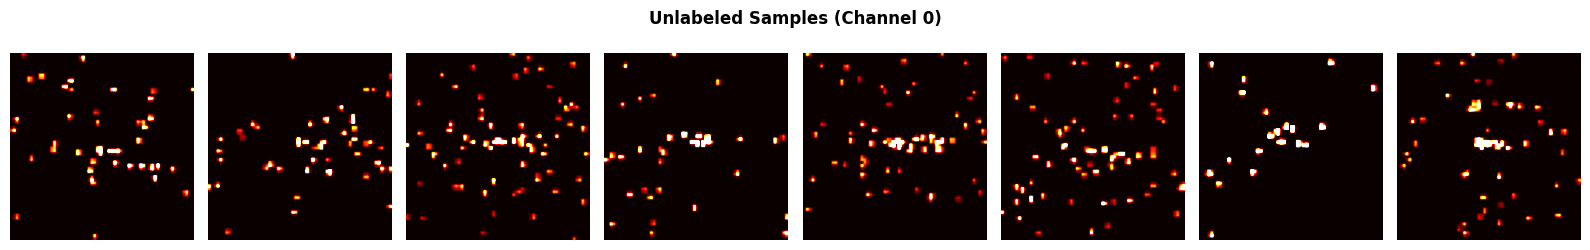


--- Labeled validation samples (log-compressed, ch 0) ---


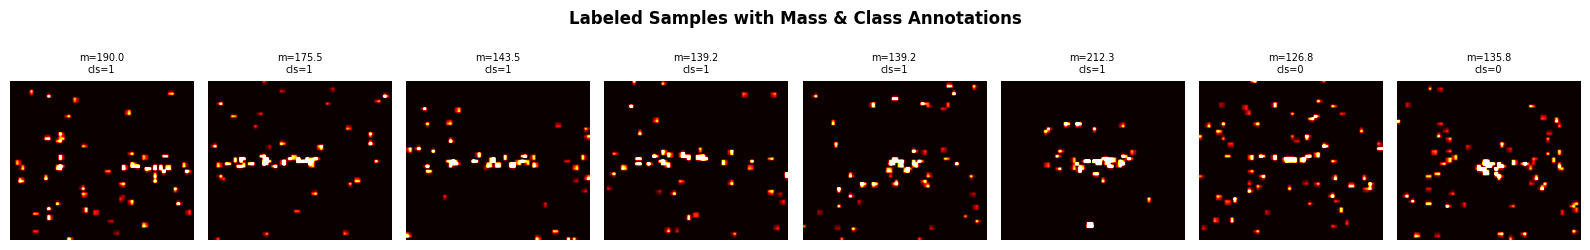

In [15]:
# ============================================================
# Section 3: Data Preprocessing & Augmentation (FIXED)
# - Handles label tensors shaped (1,) from HDF5 key 'Y'
# - Adds label distribution sanity checks
# ============================================================

import math
import random
import warnings
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt


class PhysicsPreprocess(nn.Module):
    """Physics-inspired preprocessing for detector images."""

    def __init__(self, img_size: int = 64, in_chans: int = 8, allow_fallback_zeros: bool = True):
        super().__init__()
        self.img_size = int(img_size)
        self.in_chans = int(in_chans)
        self.allow_fallback_zeros = allow_fallback_zeros

    def _fallback_image(self, device, dtype):
        return torch.zeros((self.in_chans, self.img_size, self.img_size), device=device, dtype=dtype)

    def _to_chw(self, x: torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(x):
            x = torch.as_tensor(x)
        x = x.float()

        if x.ndim == 0:
            if self.allow_fallback_zeros:
                warnings.warn("PhysicsPreprocess: scalar input encountered; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Expected image-like tensor, got scalar: {x}")

        if x.ndim == 1 and x.numel() <= 1:
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: tiny 1D input shape={tuple(x.shape)}; using zeros fallback.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Tiny 1D tensor cannot represent image: shape={tuple(x.shape)}")

        if x.ndim == 1:
            n = x.numel()
            if n % self.in_chans == 0:
                hw = n // self.in_chans
                h = int(math.isqrt(hw))
                if h * h == hw:
                    return x.view(self.in_chans, h, h)
            h = int(math.isqrt(n))
            if h * h == n:
                return x.view(1, h, h)
            if self.allow_fallback_zeros:
                warnings.warn(f"PhysicsPreprocess: cannot infer image shape from flattened length={n}; fallback zeros.")
                return self._fallback_image(x.device, x.dtype)
            raise ValueError(f"Cannot infer image shape from flattened tensor length={n}")

        if x.ndim == 2:
            return x.unsqueeze(0)

        if x.ndim == 3:
            # HWC -> CHW if last dim looks like channels
            if x.shape[-1] <= 16 and x.shape[0] > 16 and x.shape[1] > 16:
                return x.permute(2, 0, 1)
            return x

        if self.allow_fallback_zeros:
            warnings.warn(f"PhysicsPreprocess: unsupported ndim={x.ndim}, shape={tuple(x.shape)}; fallback zeros.")
            return self._fallback_image(x.device, x.dtype)
        raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._to_chw(x)

        x = torch.log1p(x.clamp(min=0.0))                 # log compression
        x = torch.where(x < 1e-3, torch.zeros_like(x), x) # noise suppression
        x = x / (x.sum() + 1e-8)                          # event normalization
        x = (x - x.mean()) / (x.std() + 1e-6)             # standardization

        if x.shape[-2] != self.img_size or x.shape[-1] != self.img_size:
            x = TF.resize(x, [self.img_size, self.img_size], antialias=True)

        c = x.shape[0]
        if c < self.in_chans:
            repeats = (self.in_chans + c - 1) // c
            x = x.repeat(repeats, 1, 1)[: self.in_chans]
        elif c > self.in_chans:
            x = x[: self.in_chans]

        return x


class AugmentTransform(nn.Module):
    """Physics-aware data augmentation."""
    def __init__(self, p: float = 0.5, noise_std: float = 0.01):
        super().__init__()
        self.p = float(p)
        self.noise_std = float(noise_std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if random.random() < self.p:
            x = torch.rot90(x, random.randint(0, 3), dims=[-2, -1])
        if random.random() < self.p:
            x = TF.hflip(x)
        if random.random() < self.p:
            x = TF.vflip(x)
        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.noise_std
        if random.random() < self.p:
            x = x * (0.9 + 0.2 * random.random())
        if random.random() < self.p:
            mask = (torch.rand_like(x) > 0.02).to(x.dtype)
            x = x * mask
        return x


class TrainTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)
        self.augment = AugmentTransform()

    def forward(self, x):
        return self.augment(self.preprocess(x))


class ValTransform(nn.Module):
    def __init__(self, img_size=64, in_chans=8):
        super().__init__()
        self.preprocess = PhysicsPreprocess(img_size=img_size, in_chans=in_chans, allow_fallback_zeros=True)

    def forward(self, x):
        return self.preprocess(x)


class TransformedDataset(Dataset):
    """Wraps base dataset + transform on image only."""
    def __init__(self, base_dataset: Dataset, transform=None):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]  # (img, mass, label)
        img = self.transform(item[0]) if self.transform is not None else item[0]

        # Critical fix: make label scalar int64 (handles shape (1,) from HDF5)
        if len(item) >= 3:
            mass = item[1]
            label = item[2]
            label = torch.as_tensor(label).view(-1)[0].to(torch.long)
            mass = torch.as_tensor(mass).view(-1)[0].to(torch.float32)
            return img, mass, label

        return (img,) + item[1:]


def compute_mass_stats(dataset):
    masses = []
    for i in range(len(dataset)):
        item = dataset[i]
        if len(item) >= 2:
            m = torch.as_tensor(item[1]).view(-1)[0].item()
            masses.append(float(m))
    if len(masses) == 0:
        return 0.0, 1.0
    masses = torch.tensor(masses, dtype=torch.float32)
    std = masses.std().item()
    if std < 1e-12:
        std = 1.0
    return masses.mean().item(), std


def get_label_dist(dataset):
    cnt = Counter()
    for i in range(len(dataset)):
        y = dataset[i][2]
        y = int(torch.as_tensor(y).view(-1)[0].item())
        cnt[y] += 1
    return cnt


# ---------------------------
# Train/Val split
# ---------------------------
n_total = len(raw_dataset)
n_train = int(n_total * TRAIN_FRAC)
n_val = n_total - n_train
generator = torch.Generator().manual_seed(SEED)
train_raw, val_raw = random_split(raw_dataset, [n_train, n_val], generator=generator)

print(f"Train samples: {n_train} | Val samples: {n_val}")

# Sanity check label distribution BEFORE transforms
dist_all = get_label_dist(raw_dataset)
dist_train = get_label_dist(train_raw)
dist_val = get_label_dist(val_raw)

print("Label distribution (full): ", dist_all)
print("Label distribution (train):", dist_train)
print("Label distribution (val):  ", dist_val)

if len(dist_all) < 2:
    raise RuntimeError(
        "Only one class detected in labeled dataset. Recheck Section 2 label_key (should be 'Y' for your file)."
    )

MASS_MEAN, MASS_STD = compute_mass_stats(train_raw)
print(f"Mass normalization: mean={MASS_MEAN:.4f}, std={MASS_STD:.4f}")

# Apply transforms
train_dataset = TransformedDataset(train_raw, TrainTransform(IMG_SIZE, IN_CHANS))
val_dataset = TransformedDataset(val_raw, ValTransform(IMG_SIZE, IN_CHANS))

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DL_NUM_WORKERS,
    pin_memory=DL_PIN_MEMORY,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


def plot_sample_images_raw(dataset: Dataset, n: int = 8, title: str = "Sample Images") -> None:
    n = min(n, len(dataset))
    if n == 0:
        print("Dataset is empty.")
        return

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    if n == 1:
        axes = [axes]

    shown, i = 0, 0
    while shown < n and i < len(dataset):
        ax = axes[shown]
        try:
            item = dataset[i]
            img = item[0]
            if img.ndim == 3:
                img = img[0]
            arr = img.detach().cpu().numpy()

            vmin = np.percentile(arr, 1)
            vmax = np.percentile(arr, 99)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
                vmin, vmax = None, None

            ax.imshow(arr, cmap="hot", aspect="auto", vmin=vmin, vmax=vmax)
            ax.axis("off")

            if len(item) >= 3:
                mass = float(torch.as_tensor(item[1]).view(-1)[0].item())
                label = int(torch.as_tensor(item[2]).view(-1)[0].item())
                ax.set_title(f"m={mass:.1f}\ncls={label}", fontsize=7)

            shown += 1
        except Exception:
            pass
        i += 1

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("\n--- Unlabeled samples (log-compressed, ch 0) ---")
unlabeled_vis = TransformedDataset(unlabeled_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
plot_sample_images_raw(unlabeled_vis, n=min(8, len(unlabeled_vis)), title="Unlabeled Samples (Channel 0)")

print("\n--- Labeled validation samples (log-compressed, ch 0) ---")
plot_sample_images_raw(val_dataset, n=min(8, len(val_dataset)), title="Labeled Samples with Mass & Class Annotations")

## Section 4: Model Architectures

Four core architectures for benchmarking:
- **StandardViT**: quadratic self-attention baseline O(N^2*d)
- **LinearAttentionViT**: ReLU kernel linear attention O(N*d^2)
- **L2ViT**: Linear Global Attention + Local Window Attention (hybrid)
- **XCiTViT**: Cross-Covariance Attention O(N*d^2) (El-Nouby et al.)

Modular design allows swapping attention mechanisms easily.

In [16]:
# ============================================================
# Section 4: Model Architectures
# StandardViT, LinearAttentionViT, L2ViT, XCiTViT
# ============================================================

import math
from functools import partial

import torch.nn.functional as F


# ----------------------------------------------------------
# Shared building blocks
# ----------------------------------------------------------

class DropPath(nn.Module):
    """Stochastic Depth (Drop Path) regularization.
    Reference: Huang et al., 2016."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


class PatchEmbed(nn.Module):
    """Image-to-patch embedding using Conv2D.
    Input: B x C x H x W -> Output: B x N x D
    Includes positional encoding via learnable embeddings."""

    def __init__(self, img_size=64, patch_size=8, in_chans=8, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)                          # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)          # (B, N, D)
        return x


class MLP(nn.Module):
    """Two-layer FFN with GELU activation and dropout."""

    def __init__(self, in_features: int, hidden_features: int = None, dropout: float = 0.0):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def _make_cls_head(in_dim: int, out_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Two-layer classification head."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, out_dim),
    )


def _make_reg_head(in_dim: int, dropout: float = 0.1) -> nn.Sequential:
    """Deeper 3-layer regression head for improved mass prediction."""
    return nn.Sequential(
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 2, in_dim // 4),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(in_dim // 4, 1),
)

class RegressionHead(nn.Module):
    """Deeper MLP regression head for mass prediction.

    Accepts concatenated CLS + mean token features (embed_dim * 2) to
    leverage both global summary and spatially-averaged representations.
    Reference: Improvement 2+3 from problem statement."""

    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)



# ----------------------------------------------------------
# 4.1  Standard Vision Transformer (ViT)
# ----------------------------------------------------------

class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention: Softmax(QK^T / sqrt(d)) V. O(N^2*d)."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class ViTBlock(nn.Module):
    """Pre-norm ViT block: x = x + Attn(LN(x)); x = x + FFN(LN(x))."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class StandardViT(nn.Module):
    """Standard Vision Transformer with quadratic self-attention.
    Reference: Dosovitskiy et al., ICLR 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                              # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                      # (B, N+1, D)
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                  # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# 4.2  Linear Attention Vision Transformer
# ----------------------------------------------------------

class LinearAttention(nn.Module):
    """Linear Attention using ReLU kernel feature maps.
    phi(Q) = ReLU(Q), phi(K) = ReLU(K)
    Attention: phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) -- linear in number of tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        # ReLU kernel feature maps
        q = F.relu(q)
        k = F.relu(k)

        # Linear attention: phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
        kv = k.transpose(-2, -1) @ v                 # (B, H, d, d)
        qkv_out = q @ kv                             # (B, H, N, d)

        # Normalization
        k_sum = k.sum(dim=-2, keepdim=True)           # (B, H, 1, d)
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-6)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LinearViTBlock(nn.Module):
    """Pre-norm transformer block using Linear Attention."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LinearAttentionViT(nn.Module):
    """Linear Attention ViT using ReLU kernel feature maps.
    phi(Q)(phi(K)^T V) / (phi(Q)(phi(K)^T 1))
    Complexity: O(N * d^2) per layer -- linear in tokens."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            LinearViTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = x + self.pos_embed                              # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                      # (B, N+1, D)
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)                                  # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# 4.3  L2ViT -- Linear Global Attention + Local Window Attention
# ----------------------------------------------------------

class LocalConcentrationModule(nn.Module):
    """Local Concentration Module (LCM) from L2ViT.
    Re-focuses dispersive linear-attention maps via depth-wise convolutions."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LinearGlobalAttention(nn.Module):
    """Linear Global Attention (LGA) from L2ViT.
    Uses ReLU kernel: phi(Q) = ReLU(Q), phi(K) = ReLU(K).
    Complexity: O(N * C^2) -- linear in tokens."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = nn.Parameter(torch.ones(1) * math.sqrt(self.head_dim))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.relu(q)
        k = F.relu(k)

        kv = k.transpose(-2, -1) @ v * self.scale
        qkv_out = q @ kv
        k_sum = k.sum(dim=-2, keepdim=True)
        normalizer = (q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-2)
        out = qkv_out / normalizer

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(out))


class LocalWindowAttention(nn.Module):
    """Local Window Attention (LWA) from L2ViT.
    Standard self-attention within non-overlapping windows."""

    def __init__(self, dim: int, num_heads: int = 8, window_size: int = 4, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.window_size = window_size
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        H = W = int(math.sqrt(N))
        ws = self.window_size

        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        x2d = x.transpose(1, 2).reshape(B, D, H, W)
        if pad_h > 0 or pad_w > 0:
            x2d = F.pad(x2d, (0, pad_w, 0, pad_h))
        Hp, Wp = x2d.shape[2], x2d.shape[3]

        nH, nW = Hp // ws, Wp // ws
        x_win = x2d.reshape(B, D, nH, ws, nW, ws)
        x_win = x_win.permute(0, 2, 4, 3, 5, 1).reshape(B * nH * nW, ws * ws, D)

        qkv = self.qkv(x_win).reshape(-1, ws * ws, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B * nH * nW, ws * ws, D)

        out = out.reshape(B, nH, nW, ws, ws, D)
        out = out.permute(0, 5, 1, 3, 2, 4).reshape(B, D, Hp, Wp)
        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H, :W]
        out = out.reshape(B, D, N).transpose(1, 2)
        return self.proj_drop(self.proj(out))


class ConditionalPositionalEncoding(nn.Module):
    """Conditional Positional Encoding via depth-wise convolution."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        return x + self.conv(x2d).reshape(B, D, N).transpose(1, 2)


class LGABlock(nn.Module):
    """L2ViT block: CPE + Linear Global Attention + LCM + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearGlobalAttention(dim, num_heads, dropout)
        self.norm_lcm = nn.LayerNorm(dim)
        self.lcm = LocalConcentrationModule(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cpe(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.lcm(self.norm_lcm(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class LWABlock(nn.Module):
    """L2ViT block: CPE + Local Window Attention + FFN."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout, drop_path, n_patches_side, window_size=4):
        super().__init__()
        self.cpe = ConditionalPositionalEncoding(dim, n_patches_side)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LocalWindowAttention(dim, num_heads, window_size, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cpe(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class L2ViT(nn.Module):
    """L2ViT: Linear Global Attention + Local Window Attention hybrid.
    Alternating pattern: LWA -> LGA -> LWA -> LGA ...
    Reference: Zheng, 'The Linear Attention Resurrection in Vision Transformer', 2025."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
        window_size=4,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList()
        for i in range(depth):
            if i % 2 == 0:
                self.blocks.append(
                    LWABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side, window_size)
                )
            else:
                self.blocks.append(
                    LGABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
                )
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)               # (B, N, D)
        for blk in self.blocks:
            x = blk(x)                                       # spatial blocks on patches only
        x = self.norm(x)                                     # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)               # (B, 1, D)
        return torch.cat([cls, x], dim=1)                    # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# 4.4  XCiT Vision Transformer (Cross-Covariance Attention)
# ----------------------------------------------------------

class CrossCovarianceAttention(nn.Module):
    """Cross-Covariance Attention (XCA) from XCiT.
    Q^T K -> d x d channel attention matrix.
    Complexity: O(N * d^2) -- linear in tokens.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(self, dim: int, num_heads: int = 8, dropout: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = F.normalize(q, dim=-2)
        k = F.normalize(k, dim=-2)

        attn = (q.transpose(-2, -1) @ k) * self.temperature
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        x = (v @ attn).transpose(1, 2).reshape(B, N, D)
        return self.proj_drop(self.proj(x))


class LocalPatchInteraction(nn.Module):
    """Local Patch Interaction (LPI) from XCiT.
    Two depth-wise 3x3 convolutions for local patch correlations."""

    def __init__(self, dim: int, n_patches_side: int):
        super().__init__()
        self.n = n_patches_side
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape
        x2d = x.transpose(1, 2).reshape(B, D, self.n, self.n)
        x2d = self.act(self.bn(self.conv1(x2d)))
        x2d = self.conv2(x2d)
        return x2d.reshape(B, D, N).transpose(1, 2)


class LayerScale(nn.Module):
    """CaiT-style learnable per-channel scaling (init to 1e-4)."""
    def __init__(self, dim: int, init_values: float = 1e-4):
        super().__init__()
        self.gamma = nn.Parameter(init_values * torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.gamma * x


class XCiTBlock(nn.Module):
    """XCiT block: XCA + LPI + FFN with LayerScale."""

    def __init__(self, dim, num_heads, mlp_ratio, dropout,
                 drop_path, n_patches_side, init_values=1e-4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = CrossCovarianceAttention(dim, num_heads, dropout)
        self.norm_lpi = nn.LayerNorm(dim)
        self.lpi = LocalPatchInteraction(dim, n_patches_side)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.ls1 = LayerScale(dim, init_values)
        self.ls2 = LayerScale(dim, init_values)
        self.ls3 = LayerScale(dim, init_values)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.ls1(self.attn(self.norm1(x))))
        x = x + self.drop_path(self.ls2(self.lpi(self.norm_lpi(x))))
        x = x + self.drop_path(self.ls3(self.mlp(self.norm2(x))))
        return x


class XCiTViT(nn.Module):
    """XCiT Vision Transformer using Cross-Covariance Attention.
    Reference: El-Nouby et al., NeurIPS 2021."""

    def __init__(
        self,
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        in_chans=IN_CHANS,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_ratio=MLP_RATIO,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
        drop_path_rate=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches
        n_side = img_size // patch_size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            XCiTBlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i], n_side)
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.regression_head = RegressionHead(embed_dim, dropout)
        self.classification_head = _make_cls_head(embed_dim, num_classes, dropout)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_encoder(self) -> None:
        for name, param in self.named_parameters():
            if "regression_head" not in name and "classification_head" not in name:
                param.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for param in self.parameters():
            param.requires_grad = True

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        B = x.shape[0]
        x = self.pos_drop(x + self.pos_embed)               # (B, N, D)
        for blk in self.blocks:
            x = blk(x)                                       # spatial blocks on patches only
        x = self.norm(x)                                     # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)               # (B, 1, D)
        return torch.cat([cls, x], dim=1)                    # (B, N+1, D)

    def forward(self, x: torch.Tensor):
        tokens = self.forward_features(x)
        cls_token = tokens[:, 0]                             # (B, D)
        mean_token = tokens[:, 1:].mean(dim=1)               # (B, D)
        features = torch.cat([cls_token, mean_token], dim=1) # (B, 2D)
        return self.regression_head(features), self.classification_head(cls_token)


# ----------------------------------------------------------
# Quick shape tests and parameter counts
# ----------------------------------------------------------

print("=" * 60)
print("Model Architecture Summary")
print("=" * 60)

_dummy = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for ModelClass in [StandardViT, LinearAttentionViT, L2ViT, XCiTViT]:
    model = ModelClass()
    mass, cls = model(_dummy)
    params = model.count_params()
    print(f"\n{ModelClass.__name__}:")
    print(f"  mass_pred shape : {mass.shape}")
    print(f"  class_logits shape: {cls.shape}")
    print(f"  Trainable params: {params:,} ({params/1e6:.2f}M)")
    del model
print("=" * 60)


Model Architecture Summary

StandardViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,235,907 (8.24M)

LinearAttentionViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,235,907 (8.24M)

L2ViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,394,632 (8.39M)

XCiTViT:
  mass_pred shape : torch.Size([2, 1])
  class_logits shape: torch.Size([2, 2])
  Trainable params: 8,305,107 (8.31M)


## Section 5: Self-Supervised Pretraining Models

Three masked-image-modeling approaches for representation learning:
- **MAEPretrainer**: Masked Autoencoder with pixel reconstruction
- **MAEv2Pretrainer**: Feature distillation with EMA teacher
- **SimMIMPretrainer**: Simple MIM with L1 pixel loss

In [17]:
# ============================================================
# Section 5: Self-Supervised Pretraining Models
# MAE, MAEv2, SimMIM for unsupervised representation learning
# ============================================================


class XCABlock(nn.Module):
    """Lightweight XCA-only block (no LPI). Works with any token count."""
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float, dropout: float, drop_path: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = CrossCovarianceAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio), dropout)
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class MAEPretrainer(nn.Module):
    """Masked Autoencoder (He et al. CVPR 2022) for self-supervised pretraining.

    Randomly masks patch tokens (mask_ratio), encodes only the visible patches
    using XCA-based linear attention blocks, then uses a lightweight transformer
    decoder to reconstruct pixel values of the masked patches.
    Loss: MSE on masked-patch pixel values only.
    """

    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        decoder_embed_dim: int = 128,
        decoder_depth: int = 4,
        decoder_num_heads: int = 4,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio
        n_side = img_size // patch_size
        self.n_patches = n_side ** 2
        self.patch_dim = in_chans * patch_size * patch_size

        # --- Encoder ---
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        dpr = [x.item() for x in torch.linspace(0, 0.1, depth)]
        self.encoder_blocks = nn.ModuleList([
            XCABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)

        # --- Decoder ---
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, self.n_patches, decoder_embed_dim)
        )
        self.decoder_blocks = nn.ModuleList([
            ViTBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio, dropout, 0.0)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, self.patch_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def patchify(self, imgs: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) -> (B, N, patch_dim)"""
        B, C, H, W = imgs.shape
        P = self.patch_size
        n = H // P
        x = imgs.reshape(B, C, n, P, n, P)
        x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, n * n, C * P * P)
        return x

    def random_masking(self, x: torch.Tensor):
        """Shuffle tokens; keep first len_keep visible, rest are masked."""
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        mask = torch.ones(B, N, device=x.device)
        mask[:, :len_keep] = 0.0
        mask = torch.gather(mask, 1, ids_restore)
        return x_vis, mask, ids_restore

    def get_encoder_state_dict(self) -> dict:
        """Return encoder weights for loading into LinearAttentionViT."""
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = self.patchify(imgs)
        x = self.patch_embed(imgs)
        x = x + self.pos_embed
        x_vis, mask, ids_restore = self.random_masking(x)
        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        x_vis = self.encoder_norm(x_vis)

        # Decode
        x_dec = self.decoder_embed(x_vis)
        B, len_keep, D_dec = x_dec.shape
        n_mask = ids_restore.shape[1] - len_keep
        mask_tokens = self.mask_token.expand(B, n_mask, -1)
        x_full = torch.cat([x_dec, mask_tokens], dim=1)
        x_full = torch.gather(
            x_full, 1,
            ids_restore.unsqueeze(-1).expand(-1, -1, D_dec)
        )
        x_full = x_full + self.decoder_pos_embed
        for blk in self.decoder_blocks:
            x_full = blk(x_full)
        x_full = self.decoder_norm(x_full)
        pred = self.decoder_pred(x_full)

        loss = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss, pred, mask


class MAEv2Pretrainer(nn.Module):
    """MAE v2 with feature distillation from a momentum-updated teacher encoder.

    The online encoder processes visible patches; the teacher encoder (EMA copy)
    processes all patches.  Loss: MSE between online predictions at masked
    positions and teacher features at those positions.  No pixel decoder needed.
    """

    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
        momentum: float = 0.996,
    ):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.momentum = momentum
        n_side = img_size // patch_size
        self.n_patches = n_side ** 2
        self.patch_dim = in_chans * patch_size * patch_size

        # Online encoder (trained via backprop)
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        dpr = [x.item() for x in torch.linspace(0, 0.1, depth)]
        self.encoder_blocks = nn.ModuleList([
            XCABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)
        self.predictor = nn.Linear(embed_dim, embed_dim)

        # Teacher encoder (EMA of online; no grad)
        self.teacher_patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.teacher_pos_embed = nn.Parameter(
            torch.zeros(1, self.n_patches, embed_dim), requires_grad=False
        )
        self.teacher_blocks = nn.ModuleList([
            XCABlock(embed_dim, num_heads, mlp_ratio, dropout, 0.0)
            for _ in range(depth)
        ])
        self.teacher_norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)
        # Initialize teacher as copy of online
        self._copy_to_teacher()
        for p in list(self.teacher_patch_embed.parameters()) + \
                 list(self.teacher_blocks.parameters()) + \
                 list(self.teacher_norm.parameters()):
            p.requires_grad = False

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    @torch.no_grad()
    def _copy_to_teacher(self):
        self.teacher_patch_embed.load_state_dict(self.patch_embed.state_dict())
        self.teacher_blocks.load_state_dict(self.encoder_blocks.state_dict())
        self.teacher_norm.load_state_dict(self.encoder_norm.state_dict())
        self.teacher_pos_embed.data.copy_(self.pos_embed.data)

    @torch.no_grad()
    def update_teacher(self):
        """EMA update of teacher from online encoder."""
        m = self.momentum
        for p_online, p_teacher in zip(
            self.encoder_blocks.parameters(), self.teacher_blocks.parameters()
        ):
            p_teacher.data.mul_(m).add_((1 - m) * p_online.data)
        for p_online, p_teacher in zip(
            self.patch_embed.parameters(), self.teacher_patch_embed.parameters()
        ):
            p_teacher.data.mul_(m).add_((1 - m) * p_online.data)

    def random_masking(self, x: torch.Tensor):
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        mask = torch.ones(B, N, device=x.device)
        mask[:, :len_keep] = 0.0
        mask = torch.gather(mask, 1, ids_restore)
        return x_vis, mask, ids_restore, ids_keep

    def forward(self, imgs: torch.Tensor):
        # Teacher: encode all patches
        with torch.no_grad():
            t = self.teacher_patch_embed(imgs) + self.teacher_pos_embed
            for blk in self.teacher_blocks:
                t = blk(t)
            t = self.teacher_norm(t)  # (B, N, D)

        # Online: encode only visible patches
        x = self.patch_embed(imgs) + self.pos_embed
        x_vis, mask, ids_restore, ids_keep = self.random_masking(x)
        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        x_vis = self.encoder_norm(x_vis)
        pred_vis = self.predictor(x_vis)  # (B, len_keep, D)

        # Gather teacher targets at visible positions for feature matching
        teacher_vis = torch.gather(
            t, 1, ids_keep.unsqueeze(-1).expand(-1, -1, t.shape[-1])
        )
        loss = F.mse_loss(pred_vis, teacher_vis.detach())
        return loss, pred_vis, mask


class SimMIMPretrainer(nn.Module):
    """Simple Masked Image Modeling (Xie et al. CVPR 2022).

    Masks random patches by replacing them with a learnable mask token,
    encodes the full (partially-masked) sequence with XCA-based blocks,
    then predicts raw pixel values via a single linear projection head.
    Loss: L1 on masked-patch pixel values only.
    """

    def __init__(
        self,
        img_size: int = IMG_SIZE,
        patch_size: int = PATCH_SIZE,
        in_chans: int = IN_CHANS,
        embed_dim: int = EMBED_DIM,
        depth: int = DEPTH,
        num_heads: int = NUM_HEADS,
        mlp_ratio: float = MLP_RATIO,
        mask_ratio: float = MASK_RATIO,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio
        n_side = img_size // patch_size
        self.n_patches = n_side ** 2
        self.patch_dim = in_chans * patch_size * patch_size

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        dpr = [x.item() for x in torch.linspace(0, 0.1, depth)]
        self.encoder_blocks = nn.ModuleList([
            XCABlock(embed_dim, num_heads, mlp_ratio, dropout, dpr[i])
            for i in range(depth)
        ])
        self.encoder_norm = nn.LayerNorm(embed_dim)
        # Simple linear prediction head
        self.pred_head = nn.Linear(embed_dim, self.patch_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def patchify(self, imgs: torch.Tensor) -> torch.Tensor:
        B, C, H, W = imgs.shape
        P = self.patch_size
        n = H // P
        x = imgs.reshape(B, C, n, P, n, P)
        x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, n * n, C * P * P)
        return x

    def get_encoder_state_dict(self) -> dict:
        return {
            "patch_embed": self.patch_embed.state_dict(),
            "pos_embed": self.pos_embed.data,
            "encoder_blocks": self.encoder_blocks.state_dict(),
            "encoder_norm": self.encoder_norm.state_dict(),
        }

    def forward(self, imgs: torch.Tensor):
        target = self.patchify(imgs)
        x = self.patch_embed(imgs)             # (B, N, D)
        B, N, D = x.shape
        # Build random mask
        noise = torch.rand(B, N, device=x.device)
        mask = (noise < self.mask_ratio).float()   # 1 = masked
        mask_expand = mask.unsqueeze(-1).expand_as(x)
        mask_tok = self.mask_token.expand(B, N, -1)
        x = x * (1 - mask_expand) + mask_tok * mask_expand
        x = x + self.pos_embed
        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.encoder_norm(x)
        pred = self.pred_head(x)               # (B, N, patch_dim)
        # L1 loss on masked patches
        loss = F.l1_loss(pred * mask.unsqueeze(-1), target * mask.unsqueeze(-1), reduction='sum')
        n_masked = mask.sum().clamp(min=1)
        loss = loss / (n_masked * self.patch_dim)
        return loss, pred, mask


print("Self-supervised pretraining models defined:")
print("  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer")

# Quick sanity check
_dummy_imgs = torch.zeros(2, IN_CHANS, IMG_SIZE, IMG_SIZE)
for _cls, _name in [(MAEPretrainer, "MAE"), (SimMIMPretrainer, "SimMIM")]:
    _m = _cls()
    _loss, _, _ = _m(_dummy_imgs)
    print(f"  {_name}: loss={_loss.item():.4f}, params={sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
    del _m


Self-supervised pretraining models defined:
  MAEPretrainer, MAEv2Pretrainer, SimMIMPretrainer
  MAE: loss=0.0513, params=8,937,296
  SimMIM: loss=0.2560, params=8,170,064


## Section 6: Training Utilities

In [18]:
import gc
import math
import pandas as pd

# ============================================================
# Section 6: Training Utilities
# Mixed-precision training, evaluation, early stopping,
# cosine LR scheduling with warmup, and model checkpointing
# ============================================================
#
# --- v2 changes ---
# • compute_loss: uses LAMBDA_REG (default 0.2), optional Huber loss
# • train_epoch: optional AMP (USE_AMP), batch-level logging, flush=True
# • evaluate_model: unchanged logic, added class_probs for ROC-AUC etc.
# • EarlyStopping: can monitor macro-F1 (higher is better)
# • EMAModel: optional exponential moving average
# • run_experiment / run_experiment_uw: checkpoint by val macro-F1,
#   tie-break with lower MAE; two-phase training option; progress logs
# ============================================================

import copy
from tqdm.auto import tqdm

# AMP imports (version-safe)
try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast


# ----------------------------------------------------------
# Loss function
# ----------------------------------------------------------

def compute_loss(mass_pred, mass_true, class_logits, class_true,
                 regression_weight=None, class_weights=None):
    """Combined CE + lambda * {MSE or Huber} loss with mass normalisation."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    mass_true_norm = (mass_true - MASS_MEAN) / (MASS_STD + 1e-8)

    if USE_HUBER_LOSS:
        reg_loss = F.smooth_l1_loss(mass_pred.squeeze(1), mass_true_norm)
    else:
        reg_loss = F.mse_loss(mass_pred.squeeze(1), mass_true_norm)

    if class_weights is not None:
        ce = F.cross_entropy(class_logits, class_true, weight=class_weights.to(class_logits.device))
    else:
        ce = F.cross_entropy(class_logits, class_true)

    total = ce + regression_weight * reg_loss
    return total, reg_loss, ce


# ----------------------------------------------------------
# Cosine schedule with linear warmup
# ----------------------------------------------------------

class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Cosine annealing with linear warmup."""

    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.eta_min = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup_epochs:
            alpha = self.last_epoch / max(1, self.warmup_epochs)
            return [base_lr * alpha for base_lr in self.base_lrs]
        else:
            progress = (self.last_epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
            return [self.eta_min + (base_lr - self.eta_min) * cosine for base_lr in self.base_lrs]


# ----------------------------------------------------------
# Exponential Moving Average (optional)
# ----------------------------------------------------------

class EMAModel:
    """Exponential Moving Average of model parameters."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)

    def apply(self, model):
        """Load EMA weights into model."""
        model.load_state_dict(self.shadow)

    def state_dict(self):
        return copy.deepcopy(self.shadow)


# ----------------------------------------------------------
# Training epoch
# ----------------------------------------------------------

def train_epoch(model, loader, optimizer, scaler, regression_weight=None,
                class_weights=None, log_every=0):
    """One training epoch with optional AMP and gradient clipping."""
    if regression_weight is None:
        regression_weight = LAMBDA_REG

    model.train()
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for batch_idx, (imgs, masses, labels) in enumerate(tqdm(loader, desc="  train", leave=False)):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        amp_enabled = USE_AMP and (DEVICE.type == "cuda")
        with autocast(device_type=DEVICE.type, enabled=amp_enabled):
            mass_pred, class_logits = model(imgs)
            loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels,
                                          regression_weight, class_weights)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        if log_every > 0 and (batch_idx + 1) % log_every == 0:
            print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

    return {"loss": total_loss / n_batches, "mse": total_mse / n_batches, "ce": total_ce / n_batches}


# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------

@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate model; denormalize mass predictions for metric computation."""
    model.eval()
    all_mass_pred, all_mass_true = [], []
    all_class_pred, all_class_true, all_class_probs = [], [], []
    total_loss = total_mse = total_ce = 0.0
    n_batches = len(loader)

    for imgs, masses, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs = imgs.to(DEVICE)
        masses = masses.to(DEVICE)
        labels = labels.to(DEVICE)

        mass_pred, class_logits = model(imgs)
        loss, mse, ce = compute_loss(mass_pred, masses, class_logits, labels)

        total_loss += loss.item()
        total_mse += mse.item()
        total_ce += ce.item()

        # Denormalize mass predictions for evaluation
        mass_pred_denorm = mass_pred.squeeze(1) * (MASS_STD + 1e-8) + MASS_MEAN
        all_mass_pred.append(mass_pred_denorm.cpu())
        all_mass_true.append(masses.cpu())
        all_class_pred.append(class_logits.argmax(dim=1).cpu())
        all_class_true.append(labels.cpu())
        all_class_probs.append(torch.softmax(class_logits, dim=1).cpu())

    return {
        "mass_pred": torch.cat(all_mass_pred).numpy(),
        "mass_true": torch.cat(all_mass_true).numpy(),
        "class_pred": torch.cat(all_class_pred).numpy(),
        "class_true": torch.cat(all_class_true).numpy(),
        "class_probs": torch.cat(all_class_probs).numpy(),
        "loss": total_loss / n_batches,
        "mse": total_mse / n_batches,
        "ce": total_ce / n_batches,
    }


# ----------------------------------------------------------
# Inference speed measurement
# ----------------------------------------------------------

@torch.no_grad()
def measure_inference_speed(model, input_shape=(1, IN_CHANS, IMG_SIZE, IMG_SIZE), n_runs=50):
    """Average inference time per sample in milliseconds."""
    model.eval()
    dummy = torch.randn(*input_shape, device=DEVICE)
    for _ in range(5):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.time() - start) / n_runs * 1000
    return elapsed


# ----------------------------------------------------------
# Early stopping (supports higher-is-better for F1)
# ----------------------------------------------------------

class EarlyStopping:
    """Early stopping with support for both lower-is-better and higher-is-better."""

    def __init__(self, patience=5, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = float("-inf") if mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        improved = False
        if self.mode == "max":
            if score > self.best_score + self.min_delta:
                improved = True
        else:
            if score < self.best_score - self.min_delta:
                improved = True

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def reset(self):
        self.best_score = float("-inf") if self.mode == "max" else float("inf")
        self.counter = 0
        self.should_stop = False

    def __call__(self, score):
        return self.step(score)


# ----------------------------------------------------------
# Uncertainty-Weighted Multi-Task Loss (Kendall et al.)
# ----------------------------------------------------------

class UncertaintyWeightedLoss(nn.Module):
    """Multi-task loss with learnable homoscedastic uncertainty weighting."""

    def __init__(self):
        super().__init__()
        self.log_sigma1 = nn.Parameter(torch.zeros(1))
        self.log_sigma2 = nn.Parameter(torch.zeros(1))

    def forward(self, ce_loss, mse_loss):
        loss = (
            ce_loss * torch.exp(-2 * self.log_sigma1) + self.log_sigma1
            + mse_loss * torch.exp(-2 * self.log_sigma2) + self.log_sigma2
        )
        return loss


# ----------------------------------------------------------
# Weighted class computation
# ----------------------------------------------------------

def compute_class_weights(loader):
    """Compute inverse-frequency class weights from a DataLoader."""
    from collections import Counter
    counts = Counter()
    for _, _, labels in loader:
        for l in labels.numpy():
            counts[int(l)] += 1
    total = sum(counts.values())
    n_classes = len(counts)
    weights = torch.zeros(n_classes)
    for c in range(n_classes):
        weights[c] = total / (n_classes * max(counts[c], 1))
    return weights


# ----------------------------------------------------------
# run_experiment: Standard CE+MSE training pipeline
# ----------------------------------------------------------

def run_experiment(model_class, model_name, train_loader, val_loader,
                   epochs=None, lr=None, weight_decay=None, patience=None,
                   lambda_reg=None, dropout_override=None, seed=None):
    """Standard training pipeline with CE + lambda*{MSE/Huber} loss.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    Supports two-phase training, EMA, and batch logging.
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if lambda_reg is None:
        lambda_reg = LAMBDA_REG
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment: {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, lambda_reg={lambda_reg}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    # Class weights for weighted CE
    class_weights = compute_class_weights(train_loader)
    print(f"  Class weights: {class_weights.tolist()}", flush=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")  # monitor macro-F1

    ema = EMAModel(model) if USE_EMA else None

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        # Two-phase training: Phase A uses tiny lambda_reg
        if TWO_PHASE_TRAINING and epoch <= PHASE_A_EPOCHS:
            effective_lambda = PHASE_A_LAMBDA
        else:
            effective_lambda = lambda_reg

        train_stats = train_epoch(model, train_loader, optimizer, scaler,
                                   regression_weight=effective_lambda,
                                   class_weights=class_weights,
                                   log_every=LOG_EVERY_N_BATCHES)

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        # Checkpoint by macro-F1 (tie-break: lower MAE)
        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"lambda_reg={effective_lambda:.3f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


# ----------------------------------------------------------
# run_experiment_uw: Uncertainty-weighted loss training pipeline
# ----------------------------------------------------------

def run_experiment_uw(model_class, model_name, train_loader, val_loader,
                      pretrained_state=None, epochs=None, lr=None,
                      weight_decay=None, patience=None, seed=None):
    """Training pipeline using UncertaintyWeightedLoss (Kendall et al.).
    Optionally loads pretrained encoder weights.

    v2: checkpoints by val macro-F1 (tie-break: lower MAE).
    """
    if epochs is None:
        epochs = EPOCHS
    if lr is None:
        lr = LR
    if weight_decay is None:
        weight_decay = WEIGHT_DECAY
    if patience is None:
        patience = ES_PATIENCE
    if seed is None:
        seed = SEED

    print(f"\n{'='*60}", flush=True)
    print(f"  Experiment (UW-Loss): {model_name}", flush=True)
    print(f"  lr={lr}, wd={weight_decay}, epochs={epochs}", flush=True)
    print(f"{'='*60}", flush=True)

    seed_everything(seed)
    model = model_class().to(DEVICE)

    if pretrained_state is not None:
        print("  Loading pretrained encoder weights...", flush=True)
        try:
            model.patch_embed.load_state_dict(pretrained_state["patch_embed"])
            model.pos_embed.data.copy_(pretrained_state["pos_embed"])
            model_blocks_sd = model.blocks.state_dict()
            pretrain_blocks_sd = pretrained_state["encoder_blocks"]
            matched = {}
            for k, v in pretrain_blocks_sd.items():
                if k in model_blocks_sd and model_blocks_sd[k].shape == v.shape:
                    matched[k] = v
            model_blocks_sd.update(matched)
            model.blocks.load_state_dict(model_blocks_sd, strict=False)
            print(f"  Loaded {len(matched)}/{len(model_blocks_sd)} block parameters from pretrained.", flush=True)
        except Exception as e:
            print(f"  Warning: partial weight loading ({e}). Continuing with random init.", flush=True)

    uw_loss = UncertaintyWeightedLoss().to(DEVICE)
    params = model.count_params()
    print(f"  Parameters: {params:,} ({params/1e6:.2f}M)", flush=True)

    ema = EMAModel(model) if USE_EMA else None

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw_loss.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    warmup_epochs = max(1, epochs // 10)
    scheduler = CosineWarmupScheduler(optimizer, warmup_epochs=warmup_epochs,
                                       total_epochs=epochs, eta_min=1e-6)
    amp_enabled = USE_AMP and (DEVICE.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)
    early_stopper = EarlyStopping(patience=patience, mode="max")  # monitor macro-F1

    best_state = None
    best_f1 = -1.0
    best_mae = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [], "val_acc": [],
               "val_f1": [], "val_bal_acc": [], "lr": []}

    start_time = time.time()
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(DEVICE)

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"  [Epoch {epoch}/{epochs}] start | lr={current_lr:.2e}", flush=True)

        model.train()
        uw_loss.train()
        total_loss = total_mse = total_ce = 0.0
        n_batches = len(train_loader)

        for batch_idx, (imgs, masses, labels) in enumerate(tqdm(train_loader, desc=f"  [{epoch}/{epochs}]", leave=False)):
            imgs, masses, labels = imgs.to(DEVICE), masses.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type, enabled=amp_enabled):
                mass_pred, class_logits = model(imgs)
                masses_norm = (masses - MASS_MEAN) / (MASS_STD + 1e-8)
                if USE_HUBER_LOSS:
                    mse = F.smooth_l1_loss(mass_pred.squeeze(1), masses_norm)
                else:
                    mse = F.mse_loss(mass_pred.squeeze(1), masses_norm)
                ce = F.cross_entropy(class_logits, labels)
                loss = uw_loss(ce, mse)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_mse += mse.item()
            total_ce += ce.item()

            if LOG_EVERY_N_BATCHES > 0 and (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
                print(f"    batch {batch_idx+1}/{n_batches} | loss={loss.item():.4f}", flush=True)

        n = len(train_loader)
        train_stats = {"loss": total_loss/n, "mse": total_mse/n, "ce": total_ce/n}

        if ema is not None:
            ema.update(model)

        val_results = evaluate_model(model, val_loader)
        val_metrics = compute_metrics(val_results)
        scheduler.step()

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_results["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_bal_acc"].append(val_metrics.get("balanced_accuracy", val_metrics["accuracy"]))
        history["lr"].append(current_lr)

        val_f1 = val_metrics["f1"]
        val_mae = val_metrics["mae"]
        if val_f1 > best_f1 or (val_f1 == best_f1 and val_mae < best_mae):
            best_f1 = val_f1
            best_mae = val_mae
            if ema is not None:
                best_state = ema.state_dict()
            else:
                best_state = copy.deepcopy(model.state_dict())

        print(
            f"  [Epoch {epoch}/{epochs}] end   | "
            f"train_loss={train_stats['loss']:.4f} | "
            f"val_loss={val_results['loss']:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_mae={val_mae:.4f}",
            flush=True,
        )

        if early_stopper(val_f1):
            print(f"  Early stop at epoch {epoch} (best F1={best_f1:.4f})", flush=True)
            break

    train_time = time.time() - start_time
    peak_mem = 0.0
    if DEVICE.type == "cuda":
        peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1e6

    if best_state is not None:
        model.load_state_dict(best_state)
    final_results = evaluate_model(model, val_loader)
    final_metrics = compute_metrics(final_results)
    print_metrics(final_metrics, f"{model_name} -- Final Metrics")

    inference_ms = measure_inference_speed(model)
    print(f"  Inference speed: {inference_ms:.2f} ms/sample", flush=True)
    print(f"  Training time: {train_time:.1f}s | Peak GPU: {peak_mem:.0f} MB", flush=True)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "model_state": copy.deepcopy(model.state_dict()),
        "history": history,
        "final_metrics": final_metrics,
        "final_results": final_results,
        "train_time": train_time,
        "params": params,
        "peak_gpu_mem_mb": peak_mem,
        "inference_ms": inference_ms,
    }


print("Training utilities defined (v2):", flush=True)
print("  - compute_loss (CE + lambda*{MSE|Huber} with mass normalization)", flush=True)
print("  - CosineWarmupScheduler (cosine annealing with linear warmup)", flush=True)
print("  - EMAModel (optional exponential moving average)", flush=True)
print("  - train_epoch (optional AMP + gradient clipping + batch logging)", flush=True)
print("  - evaluate_model (no_grad evaluation with mass denormalization + class_probs)", flush=True)
print("  - measure_inference_speed (ms per sample)", flush=True)
print("  - EarlyStopping (patience-based, supports max/min mode)", flush=True)
print("  - UncertaintyWeightedLoss (Kendall et al.)", flush=True)
print("  - compute_class_weights (inverse-frequency weighting)", flush=True)
print("  - run_experiment (standard CE+MSE/Huber, checkpoint by F1)", flush=True)
print("  - run_experiment_uw (uncertainty-weighted, checkpoint by F1)", flush=True)


# ----------------------------------------------------------
# TrainConfig: structured hyperparameter container
# ----------------------------------------------------------

from dataclasses import dataclass as _dataclass

@_dataclass
class TrainConfig:
    """Hyperparameter container for run_experiment_fixed."""
    epochs: int = 35
    lr: float = 3e-4
    weight_decay: float = 1e-4
    patience: int = 8
    lambda_reg: float = 0.2
    grad_clip: float = 1.0
    use_amp: bool = False
    use_ema: bool = False
    ema_decay: float = 0.999
    scheduler_tmax: int = 35
    min_lr: float = 1e-6


# ----------------------------------------------------------
# run_experiment_fixed: TrainConfig-aware wrapper
# ----------------------------------------------------------

def run_experiment_fixed(model_class, model_name, train_loader, val_loader,
                         train_cfg,
                         mass_mean=None, mass_std=None,
                         pretrained_state=None, seed=None):
    """Adapter around run_experiment that accepts a TrainConfig object.

    Temporarily overrides the USE_AMP, USE_EMA, and GRAD_CLIP_NORM module
    globals so that the underlying train_epoch picks up the correct values,
    then restores them when done.

    Returns the same dict as run_experiment, plus a 'model' key holding the
    live model with best weights already loaded.
    """
    _nb = globals()
    _orig_amp  = _nb.get("USE_AMP",        False)
    _orig_ema  = _nb.get("USE_EMA",        False)
    _orig_clip = _nb.get("GRAD_CLIP_NORM", 1.0)

    _nb["USE_AMP"]        = train_cfg.use_amp
    _nb["USE_EMA"]        = train_cfg.use_ema
    _nb["GRAD_CLIP_NORM"] = train_cfg.grad_clip

    try:
        result = run_experiment(
            model_class=model_class,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=train_cfg.epochs,
            lr=train_cfg.lr,
            weight_decay=train_cfg.weight_decay,
            patience=train_cfg.patience,
            lambda_reg=train_cfg.lambda_reg,
            seed=seed,
        )
    finally:
        _nb["USE_AMP"]        = _orig_amp
        _nb["USE_EMA"]        = _orig_ema
        _nb["GRAD_CLIP_NORM"] = _orig_clip

    # Re-instantiate model and load best weights so callers can use out["model"]
    best_model = model_class().to(DEVICE)
    best_model.load_state_dict(result["model_state"])
    best_model.eval()
    result["model"] = best_model
    return result


# ----------------------------------------------------------
# benchmark_inference_ms_per_sample: DataLoader-based latency
# ----------------------------------------------------------

def benchmark_inference_ms_per_sample(model, val_loader, device=None,
                                       use_amp=False,
                                       warmup_batches=5, max_batches=30):
    """Measure mean inference latency (ms/sample) over real validation batches.

    Returns float: milliseconds per sample.
    """
    import time as _time
    if device is None:
        device = DEVICE
    model.eval()
    total_time    = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            imgs = batch[0].to(device)
            _use_amp = use_amp and device.type == "cuda"
            amp_ctx  = autocast(device_type=device.type, enabled=_use_amp)

            if batch_idx < warmup_batches:
                with amp_ctx:
                    _ = model(imgs)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                continue

            if batch_idx >= warmup_batches + max_batches:
                break

            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = _time.perf_counter()
            with amp_ctx:
                _ = model(imgs)
            if device.type == "cuda":
                torch.cuda.synchronize()
            total_time    += _time.perf_counter() - t0
            total_samples += imgs.size(0)

    if total_samples == 0:
        return float("nan")
    return (total_time / total_samples) * 1000.0


print("  - TrainConfig (dataclass for hyperparameter bundles)", flush=True)
print("  - run_experiment_fixed (TrainConfig-aware adapter)", flush=True)
print("  - benchmark_inference_ms_per_sample (DataLoader-based latency)", flush=True)


Training utilities defined:
  - compute_loss (CE + lambda*MSE with mass normalization)
  - CosineWarmupScheduler (cosine annealing with linear warmup)
  - train_epoch (AMP + gradient clipping)
  - evaluate_model (no_grad evaluation with mass denormalization)
  - measure_inference_speed (ms per sample)
  - EarlyStopping (patience-based)
  - UncertaintyWeightedLoss (Kendall et al.)
  - run_experiment (standard CE+MSE pipeline)
  - run_experiment_uw (uncertainty-weighted pipeline)


## Section 7: Evaluation Metrics

In [19]:
# ============================================================
# Section 6: Evaluation Metrics
# Full suite of classification + regression metrics
# ============================================================
#
# --- v2 changes ---
# • Added balanced_accuracy, roc_auc, pr_auc, ece
# • NaN/Inf safety for all metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)


def _safe_finite(arr):
    """Replace NaN/Inf with 0 for safe metric computation."""
    arr = np.asarray(arr, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, 0.0)
    return arr


def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error."""
    probs = _safe_finite(probs)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(labels) if len(labels) > 0 else 0.0


def compute_metrics(eval_results: dict) -> dict:
    """
    Compute comprehensive classification and regression metrics.

    Parameters
    ----------
    eval_results : dict
        Output of evaluate_model(). Must have keys:
        mass_pred, mass_true, class_pred, class_true.
        Optionally: class_probs (for ROC-AUC, PR-AUC, ECE).

    Returns
    -------
    dict with keys:
        accuracy, balanced_accuracy, f1, precision, recall, confusion_matrix,
        roc_auc, pr_auc, ece  (classification)
        mse, mae, r2          (regression)
    """
    y_true = eval_results["class_true"]
    y_pred = eval_results["class_pred"]
    m_true = _safe_finite(eval_results["mass_true"])
    m_pred = _safe_finite(eval_results["mass_pred"])

    metrics = {
        # Classification
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        # Regression
        "mse": mean_squared_error(m_true, m_pred),
        "mae": mean_absolute_error(m_true, m_pred),
        "r2": r2_score(m_true, m_pred) if len(set(m_true)) > 1 else 0.0,
    }

    # ROC-AUC, PR-AUC, ECE (require class probabilities)
    if "class_probs" in eval_results:
        probs = _safe_finite(eval_results["class_probs"])
        try:
            if probs.shape[1] == 2:
                metrics["roc_auc"] = roc_auc_score(y_true, probs[:, 1])
                metrics["pr_auc"] = average_precision_score(y_true, probs[:, 1])
            else:
                metrics["roc_auc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
                metrics["pr_auc"] = 0.0  # not well-defined for multiclass
        except (ValueError, IndexError):
            metrics["roc_auc"] = 0.0
            metrics["pr_auc"] = 0.0
        metrics["ece"] = compute_ece(probs, y_true)
    else:
        metrics["roc_auc"] = 0.0
        metrics["pr_auc"] = 0.0
        metrics["ece"] = 0.0

    return metrics


def print_metrics(metrics: dict, title: str = "Metrics") -> None:
    """Pretty-print a metrics dictionary."""
    print(f"\n{'='*50}", flush=True)
    print(f"  {title}", flush=True)
    print(f"{'='*50}", flush=True)
    print(f"  Classification:", flush=True)
    print(f"    Accuracy       : {metrics['accuracy']:.4f}", flush=True)
    print(f"    Balanced Acc.  : {metrics.get('balanced_accuracy', 0):.4f}", flush=True)
    print(f"    F1 (macro)     : {metrics['f1']:.4f}", flush=True)
    print(f"    Precision      : {metrics['precision']:.4f}", flush=True)
    print(f"    Recall         : {metrics['recall']:.4f}", flush=True)
    print(f"    ROC-AUC        : {metrics.get('roc_auc', 0):.4f}", flush=True)
    print(f"    PR-AUC         : {metrics.get('pr_auc', 0):.4f}", flush=True)
    print(f"    ECE            : {metrics.get('ece', 0):.4f}", flush=True)
    print(f"  Regression:", flush=True)
    print(f"    MSE            : {metrics['mse']:.4f}", flush=True)
    print(f"    MAE            : {metrics['mae']:.4f}", flush=True)
    print(f"    R²             : {metrics['r2']:.4f}", flush=True)
    print(f"{'='*50}", flush=True)


print("Metrics functions defined: compute_metrics(), print_metrics(), compute_ece()", flush=True)


Metrics functions defined: compute_metrics(), print_metrics()


## Section 8: Visualization Tools

In [20]:
# ============================================================
# Section 7: Visualization Tools
# Plotting functions for training curves, metrics, and images
# ============================================================

import seaborn as sns
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})


def plot_training_curves(history: dict, title: str = "Training Curves") -> None:
    """
    Plot loss and accuracy vs epoch for a single model.

    Parameters
    ----------
    history : dict
        Keys: train_loss, val_loss, val_acc (lists, one value per epoch).
    title : str
        Figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", linewidth=2, linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", linewidth=2, color="green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title} — Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_mass_scatter(
    true_mass: np.ndarray,
    pred_mass: np.ndarray,
    title: str = "Mass Prediction",
) -> None:
    """
    Scatter plot of true vs predicted particle mass with R² annotation.

    Parameters
    ----------
    true_mass : array (N,)
    pred_mass : array (N,)
    title : str
    """
    r2 = r2_score(true_mass, pred_mass)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(true_mass, pred_mass, alpha=0.3, s=10, edgecolors="none")
    lims = [min(true_mass.min(), pred_mass.min()), max(true_mass.max(), pred_mass.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Predicted Mass")
    ax.set_title(f"{title}\n$R^2 = {r2:.4f}$")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: list = None,
    title: str = "Confusion Matrix",
) -> None:
    """
    Heatmap of the confusion matrix using seaborn.

    Parameters
    ----------
    cm : array (n_classes, n_classes)
    class_names : list of str
    title : str
    """
    if class_names is None:
        class_names = [str(i) for i in range(len(cm))]
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_sample_images(
    dataset: Dataset,
    n: int = 8,
    title: str = "Sample Images",
) -> None:
    """
    Visualize a grid of detector images (first channel shown in false color).

    Parameters
    ----------
    dataset : Dataset  (returns (img, ...) tuples)
    n : int  number of images to show
    title : str
    """
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    for i, ax in enumerate(axes):
        if i >= len(dataset):
            break
        item = dataset[i]
        img = item[0]
        if img.ndim == 3:
            img = img[0]
        ax.imshow(img.numpy(), cmap="hot", aspect="auto")
        ax.axis("off")
        if len(item) >= 3:
            ax.set_title(f"m={item[1].item():.1f}\ncls={int(item[2])}", fontsize=7)
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_comparison_curves(
    all_histories: dict,
    metric_name: str = "val_loss",
) -> None:
    """
    Overlay training curves from multiple models for comparison.

    Parameters
    ----------
    all_histories : dict  {model_name: history_dict}
    metric_name : str  key in history_dict to plot
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, history in all_histories.items():
        vals = history.get(metric_name, [])
        epochs = range(1, len(vals) + 1)
        ax.plot(epochs, vals, linewidth=2, label=model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_title(f"Comparison: {metric_name.replace('_', ' ').title()}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




def visualize_attention_maps(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
    num_images: int = 4,
) -> None:
    """Extract and visualize transformer attention maps overlaid on detector images.

    Hooks into the first XCA block's temperature-weighted cross-covariance
    attention to extract the attention matrix, then overlays a heatmap on the
    first channel of each input image.

    Parameters
    ----------
    model : nn.Module  (LinearAttentionViT or similar with .blocks)
    images : Tensor (B, C, H, W)   -- raw (preprocessed) images
    device : torch.device
    num_images : int   -- how many images to plot (<= B)
    """
    model.eval()
    attn_maps = {}

    def _hook(module, inp, out):
        # Re-derive attention from the stored temperature
        with torch.no_grad():
            x = inp[0]
            B, N, D = x.shape
            qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, module.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, _ = qkv.unbind(0)
            q = F.normalize(q, dim=-2)
            k = F.normalize(k, dim=-2)
            attn = (q.transpose(-2, -1) @ k) * module.temperature  # (B, H, d, d)
            attn = F.softmax(attn, dim=-1)
            attn_maps["attn"] = attn.detach().cpu()

    # Find the first attention block
    hook_handle = None
    for blk in model.blocks:
        if hasattr(blk, "attn"):
            hook_handle = blk.attn.register_forward_hook(_hook)
            break

    if hook_handle is None:
        print("No attention block found in model.")
        return

    images_dev = images[:num_images].to(device)
    with torch.no_grad():
        _ = model(images_dev)
    hook_handle.remove()

    if "attn" not in attn_maps:
        print("Attention hook did not fire.")
        return

    attn = attn_maps["attn"]  # (B, H, d, d)
    n_show = min(num_images, attn.shape[0])

    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    if n_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_show):
        img_ch0 = images[i, 0].cpu().numpy()
        axes[0, i].imshow(img_ch0, cmap="hot")
        axes[0, i].set_title(f"Image {i} (ch0)", fontsize=8)
        axes[0, i].axis("off")

        # Average attention over heads
        attn_mean = attn[i].mean(0).numpy()  # (d, d)
        axes[1, i].imshow(attn_mean, cmap="viridis")
        axes[1, i].set_title(f"Attn Map {i}", fontsize=8)
        axes[1, i].axis("off")

    plt.suptitle("Attention Maps (XCA cross-covariance, avg over heads)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Attention map shape (B, H, d, d): {tuple(attn_maps['attn'].shape)}")


print("Visualization functions defined:")
for fn in ["plot_training_curves", "plot_mass_scatter", "plot_confusion_matrix",
           "plot_sample_images", "plot_comparison_curves", "visualize_attention_maps"]:
    print(f"  - {fn}()")


Visualization functions defined:
  - plot_training_curves()
  - plot_mass_scatter()
  - plot_confusion_matrix()
  - plot_sample_images()
  - plot_comparison_curves()
  - visualize_attention_maps()


## Section 9: Self-Supervised Pretraining

Pretrain the XCiTViT encoder using SimMIM before fine-tuning on the labeled dataset.

Self-Supervised Pretraining (SimMIM)
[LazyHDF5Dataset] file=C:\Users\Rahul\Desktop\AA Gsoc'26\data\Dataset_Specific_Unlabelled.h5
  img_key=jet
Pretraining samples: 60000 | batches: 1875
SimMIM parameters: 8,170,064 (8.17M)


  Epoch   5/30 | loss=0.0884


  Epoch  10/30 | loss=0.0858


  Epoch  15/30 | loss=0.0846


  Epoch  20/30 | loss=0.0836


  Epoch  25/30 | loss=0.0830


  Epoch  30/30 | loss=0.0830

Pretraining complete in 9480.6s
Encoder weights saved to project path: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\simmim_encoder_xcit_pretrain.pt


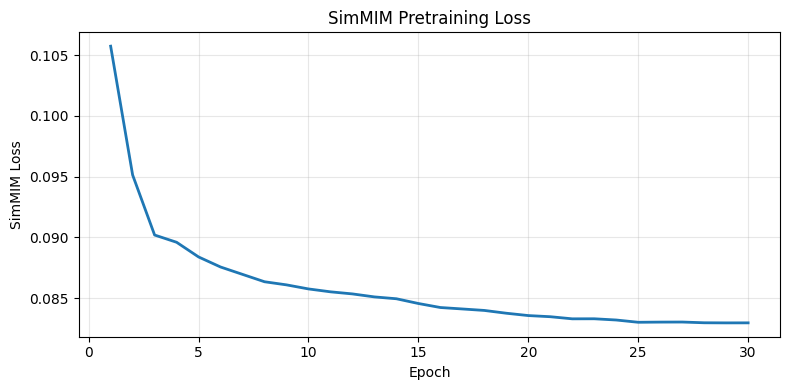

In [21]:
# ============================================================
# Section 9: Self-Supervised Pretraining (FIXED)
# - HDF5 only (no synthetic fallback)
# - AMP compatible
# - Saves encoder weights to project checkpoint path (NOT temp)
# ============================================================

import gc
import time
from pathlib import Path
from contextlib import nullcontext
from tqdm import tqdm

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# --- AMP compatibility (old/new PyTorch) ---
try:
    from torch.amp import autocast as amp_autocast  # newer API
except Exception:
    amp_autocast = None

try:
    from torch.cuda.amp import GradScaler
except Exception:
    GradScaler = None


def get_autocast_context(device: torch.device, enabled: bool):
    if not enabled or device.type != "cuda":
        return nullcontext()

    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            return amp_autocast(enabled=True)

    from torch.cuda.amp import autocast as cuda_autocast
    return cuda_autocast(enabled=True)


print("=" * 60)
print("Self-Supervised Pretraining (SimMIM)")
print("=" * 60)

# ----------------------------------------------------------
# Build unlabeled loader (HDF5 required)
# ----------------------------------------------------------
if not UNLABELED_FILE.exists():
    raise FileNotFoundError(f"Unlabeled HDF5 file not found: {UNLABELED_FILE}")

# Use explicit key to avoid key-inference surprises
pretrain_dataset_raw = LazyHDF5Dataset(
    UNLABELED_FILE,
    labeled=False,
    img_key="jet",
)

pretrain_dataset = TransformedDataset(pretrain_dataset_raw, ValTransform(IMG_SIZE, IN_CHANS))
pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

print(f"Pretraining samples: {len(pretrain_dataset)} | batches: {len(pretrain_loader)}")

seed_everything(SEED)
pretrain_model = SimMIMPretrainer().to(DEVICE)
pretrain_params = sum(p.numel() for p in pretrain_model.parameters() if p.requires_grad)
print(f"SimMIM parameters: {pretrain_params:,} ({pretrain_params/1e6:.2f}M)")

pretrain_optimizer = torch.optim.AdamW(
    pretrain_model.parameters(),
    lr=LR_PRETRAIN,
    weight_decay=WEIGHT_DECAY
)
pretrain_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    pretrain_optimizer,
    T_max=PRETRAIN_EPOCHS,
    eta_min=1e-6
)

use_amp = (DEVICE.type == "cuda")
pretrain_scaler = GradScaler(enabled=use_amp) if GradScaler is not None else None

# --- Safety assertion: ensure full-run epochs ---
assert PRETRAIN_EPOCHS >= 10, (
    f"PRETRAIN_EPOCHS={PRETRAIN_EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and PRETRAIN_EPOCHS>=10."
)
print(f"[FULL RUN] Pretraining SimMIM for {PRETRAIN_EPOCHS} epochs", flush=True)

pretrain_losses = []
pretrain_start = time.time()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    pretrain_model.train()
    ep_loss = 0.0

    for batch in tqdm(pretrain_loader, desc=f"  pretrain [{epoch}/{PRETRAIN_EPOCHS}]", leave=False):
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs = imgs.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))

        pretrain_optimizer.zero_grad(set_to_none=True)

        with get_autocast_context(DEVICE, enabled=use_amp):
            loss, _, _ = pretrain_model(imgs)

        if pretrain_scaler is not None:
            pretrain_scaler.scale(loss).backward()
            pretrain_scaler.unscale_(pretrain_optimizer)
            nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
            pretrain_scaler.step(pretrain_optimizer)
            pretrain_scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
            pretrain_optimizer.step()

        ep_loss += float(loss.item())

    ep_loss /= max(1, len(pretrain_loader))
    pretrain_losses.append(ep_loss)
    pretrain_scheduler.step()

    if epoch % 5 == 0 or epoch == PRETRAIN_EPOCHS:
        print(f"  Epoch {epoch:3d}/{PRETRAIN_EPOCHS} | loss={ep_loss:.4f}")

pretrain_time = time.time() - pretrain_start
print(f"\nPretraining complete in {pretrain_time:.1f}s")

# ----------------------------------------------------------
# Save encoder weights to project checkpoint path
# ----------------------------------------------------------
CKPT_DIR = Path("../checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_ENCODER_PATH = CKPT_DIR / "simmim_encoder_xcit_pretrain.pt"
pretrained_encoder_state = pretrain_model.get_encoder_state_dict()
torch.save(pretrained_encoder_state, PRETRAINED_ENCODER_PATH)
PRETRAINED_ENCODER_PATH = str(PRETRAINED_ENCODER_PATH.resolve())

print(f"Encoder weights saved to project path: {PRETRAINED_ENCODER_PATH}")

# Plot pretraining loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pretrain_losses) + 1), pretrain_losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("SimMIM Loss")
plt.title("SimMIM Pretraining Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cleanup
del pretrain_model
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

## Section 10: Fine-tune Pretrained XCiTViT

Load SimMIM encoder weights and fine-tune with UncertaintyWeightedLoss.

Loading pretrained encoder weights from: C:\Users\Rahul\Desktop\AA Gsoc'26\checkpoints\simmim_encoder_xcit_pretrain.pt

  Experiment (UW-Loss): XCiT ViT (pretrained)
  Loading pretrained encoder weights...
  Loaded 120/260 block parameters from pretrained.
  Parameters: 8,305,107 (8.31M)


  Epoch   5/20 | train_loss=1.0960 | val_loss=1.2605 | val_acc=0.5075 | lr=2.91e-04


  Epoch  10/20 | train_loss=0.9488 | val_loss=1.1123 | val_acc=0.5075 | lr=2.02e-04


  Epoch  15/20 | train_loss=0.8908 | val_loss=1.0668 | val_acc=0.5075 | lr=7.58e-05


  Epoch  20/20 | train_loss=0.8687 | val_loss=1.0657 | val_acc=0.5075 | lr=3.27e-06



  XCiT ViT (pretrained) -- Final Metrics
  Classification:
    Accuracy  : 0.5075
    F1 (macro): 0.3367
    Precision : 0.2537
    Recall    : 0.5000
  Regression:
    MSE       : 952.4294
    MAE       : 21.1208
    R²        : 0.6741
  Inference speed: 25.32 ms/sample
  Training time: 1329.7s | Peak GPU: 738 MB

Fine-tuning complete.


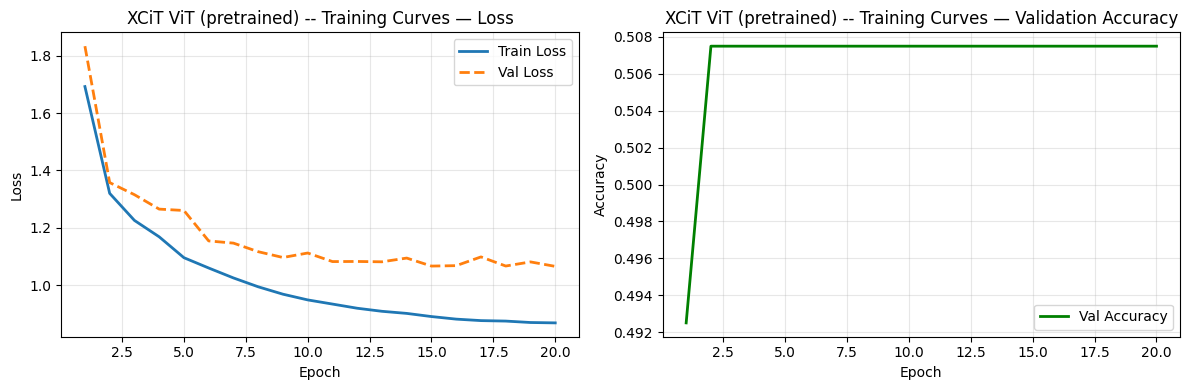

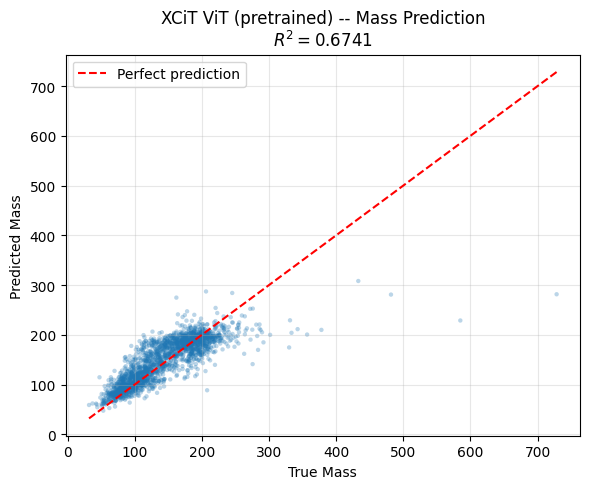

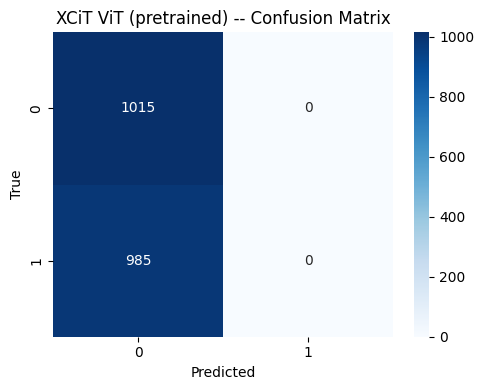

In [22]:
# ============================================================
# Section 10: Fine-tune Pretrained XCiTViT
# (PyTorch-version-safe loading + AMP compatibility patch)
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import torch

# ---- AMP compatibility helper ----
try:
    # Newer torch API
    from torch.amp import autocast as amp_autocast
except Exception:
    amp_autocast = None

try:
    # Works for older/newer CUDA AMP paths
    from torch.cuda.amp import autocast as cuda_autocast
except Exception:
    cuda_autocast = None


def get_autocast_context(device, enabled=True):
    """Return a compatible autocast context across PyTorch versions."""
    if not enabled or device.type != "cuda":
        return nullcontext()

    # Prefer new API if available
    if amp_autocast is not None:
        try:
            return amp_autocast(device_type="cuda", enabled=True)
        except TypeError:
            try:
                return amp_autocast(enabled=True)
            except Exception:
                pass

    # Fallback old CUDA AMP API
    if cuda_autocast is not None:
        return cuda_autocast(enabled=True)

    return nullcontext()


# ---- Patch run_experiment_uw to use compatible autocast ----
# If run_experiment_uw uses global name `autocast`, override it safely here.
autocast = lambda *args, **kwargs: get_autocast_context(DEVICE, enabled=(DEVICE.type == "cuda"))

# ---- Use project checkpoint path from Section 9 ----
PRETRAINED_ENCODER_PATH = str(Path("../checkpoints/simmim_encoder_xcit_pretrain.pt").resolve())
print("Loading pretrained encoder weights from:", PRETRAINED_ENCODER_PATH)

if not Path(PRETRAINED_ENCODER_PATH).exists():
    raise FileNotFoundError(
        f"Pretrained weights not found at: {PRETRAINED_ENCODER_PATH}\n"
        f"Run Section 9 first to generate this checkpoint."
    )

# torch.load compatibility across versions
try:
    pretrained_encoder_state = torch.load(
        PRETRAINED_ENCODER_PATH, map_location="cpu", weights_only=True
    )
except TypeError:
    # older torch without weights_only
    pretrained_encoder_state = torch.load(PRETRAINED_ENCODER_PATH, map_location="cpu")

# Run fine-tuning
# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training XCiT ViT (pretrained) for {EPOCHS} epochs", flush=True)

result_pretrained = run_experiment_uw(
    model_class=XCiTViT,
    model_name="XCiT ViT (pretrained)",
    train_loader=train_loader,
    val_loader=val_loader,
    pretrained_state=pretrained_encoder_state,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

print("\nFine-tuning complete.")

plot_training_curves(
    result_pretrained["history"],
    title="XCiT ViT (pretrained) -- Training Curves"
)

plot_mass_scatter(
    result_pretrained["final_results"]["mass_true"],
    result_pretrained["final_results"]["mass_pred"],
    title="XCiT ViT (pretrained) -- Mass Prediction",
)

plot_confusion_matrix(
    result_pretrained["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="XCiT ViT (pretrained) -- Confusion Matrix",
)

In [23]:
from collections import Counter
import numpy as np
import h5py

print("=== Dataset key sanity ===")
print("raw_dataset keys -> img_key:", raw_dataset.img_key, "mass_key:", raw_dataset.mass_key, "label_key:", raw_dataset.label_key)

# Full labeled distribution from raw_dataset
cnt_all = Counter()
for i in range(len(raw_dataset)):
    y = raw_dataset[i][2]
    y = int(y.item()) if hasattr(y, "item") else int(y)
    cnt_all[y] += 1
print("Full labeled distribution:", cnt_all)

# Train/Val distribution
cnt_train, cnt_val = Counter(), Counter()
for i in range(len(train_dataset)):
    y = train_dataset[i][2]
    y = int(y.item()) if hasattr(y, "item") else int(y)
    cnt_train[y] += 1
for i in range(len(val_dataset)):
    y = val_dataset[i][2]
    y = int(y.item()) if hasattr(y, "item") else int(y)
    cnt_val[y] += 1
print("Train distribution:", cnt_train)
print("Val distribution  :", cnt_val)

# Quick model prediction diversity
model = result_pretrained.get("model", None) if isinstance(result_pretrained, dict) else None
if model is not None:
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, masses, labels in val_loader:
            imgs = imgs.to(DEVICE)
            _, logits = model(imgs)
            p = logits.argmax(dim=1).cpu().numpy().tolist()
            t = labels.numpy().tolist()
            preds.extend(p); trues.extend(t)
    print("Unique val labels:", sorted(set(trues)))
    print("Unique val preds :", sorted(set(preds)))

=== Dataset key sanity ===
raw_dataset keys -> img_key: jet mass_key: m label_key: Y
Full labeled distribution: Counter({0: 5122, 1: 4878})
Train distribution: Counter({0: 4107, 1: 3893})
Val distribution  : Counter({0: 1015, 1: 985})


## Section 11: Train XCiT ViT from Scratch

Train XCiT ViT with uncertainty-weighted loss from random initialization.
Compare with pretrained version to measure pretraining benefit.


  Experiment (UW-Loss): XCiT ViT (scratch)
  Parameters: 8,305,107 (8.31M)


  Epoch   5/20 | train_loss=1.0283 | val_loss=1.2926 | val_acc=0.5075 | lr=2.91e-04


  Epoch  10/20 | train_loss=0.9202 | val_loss=1.1578 | val_acc=0.5075 | lr=2.02e-04


  Epoch  15/20 | train_loss=0.8482 | val_loss=1.0510 | val_acc=0.5075 | lr=7.58e-05


  Epoch  20/20 | train_loss=0.8233 | val_loss=1.0519 | val_acc=0.5075 | lr=3.27e-06



  XCiT ViT (scratch) -- Final Metrics
  Classification:
    Accuracy  : 0.5075
    F1 (macro): 0.3367
    Precision : 0.2537
    Recall    : 0.5000
  Regression:
    MSE       : 906.7664
    MAE       : 20.3479
    R²        : 0.6897
  Inference speed: 23.91 ms/sample
  Training time: 1323.3s | Peak GPU: 738 MB

XCiT ViT (scratch) training complete.


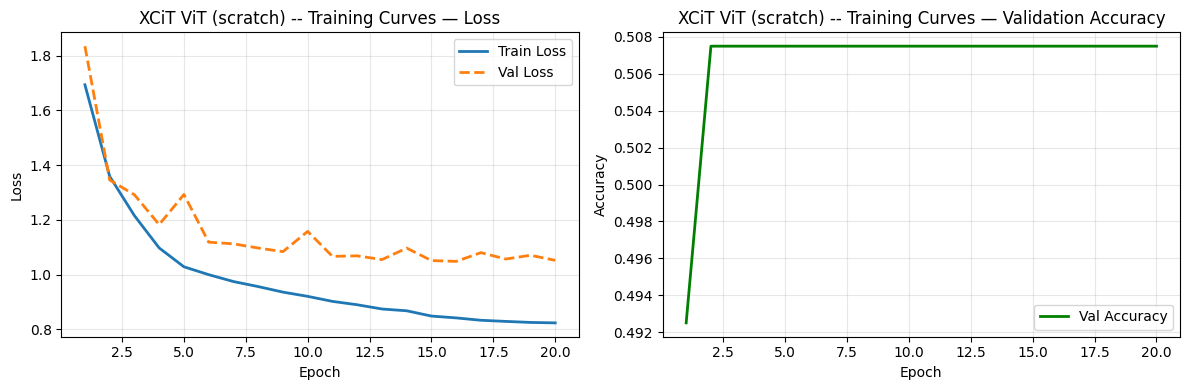

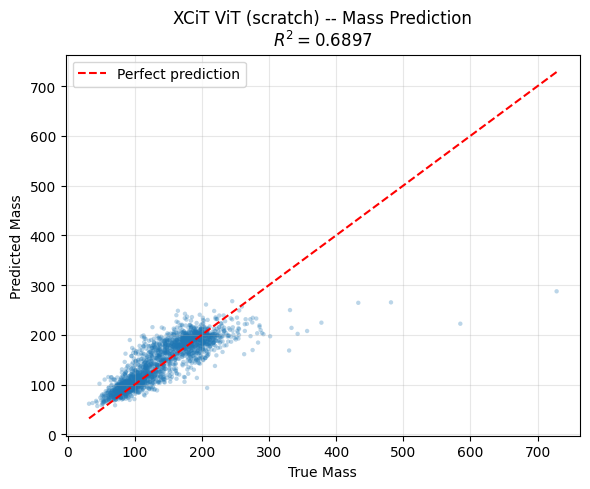

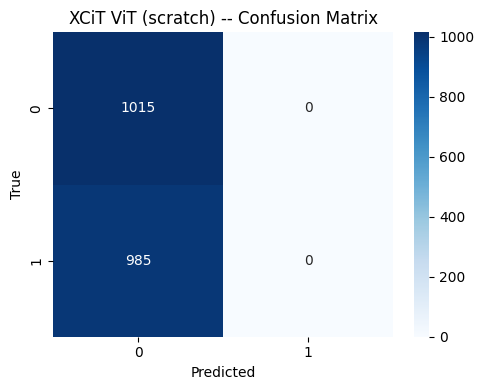

In [24]:
# ============================================================
# Section 11: Train XCiT ViT from Scratch
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training XCiT ViT (scratch) for {EPOCHS} epochs", flush=True)

result_scratch = run_experiment_uw(
    model_class=XCiTViT,
    model_name="XCiT ViT (scratch)",
    train_loader=train_loader,
    val_loader=val_loader,
    pretrained_state=None,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nXCiT ViT (scratch) training complete.")
plot_training_curves(result_scratch["history"], title="XCiT ViT (scratch) -- Training Curves")
plot_mass_scatter(
    result_scratch["final_results"]["mass_true"],
    result_scratch["final_results"]["mass_pred"],
    title="XCiT ViT (scratch) -- Mass Prediction",
)
plot_confusion_matrix(
    result_scratch["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="XCiT ViT (scratch) -- Confusion Matrix",
)

## Section 12: Train Standard ViT


  Experiment (UW-Loss): Standard ViT
  Parameters: 8,235,907 (8.24M)


  Epoch   5/20 | train_loss=0.7575 | val_loss=0.8121 | val_acc=0.8595 | lr=2.91e-04


  Epoch  10/20 | train_loss=0.6111 | val_loss=1.0213 | val_acc=0.8360 | lr=2.02e-04


  Early stop at epoch 11



  Standard ViT -- Final Metrics
  Classification:
    Accuracy  : 0.8595
    F1 (macro): 0.8590
    Precision : 0.8673
    Recall    : 0.8606
  Regression:
    MSE       : 1184.1394
    MAE       : 22.4249
    R²        : 0.5948
  Inference speed: 14.84 ms/sample
  Training time: 577.7s | Peak GPU: 699 MB

Standard ViT training complete.


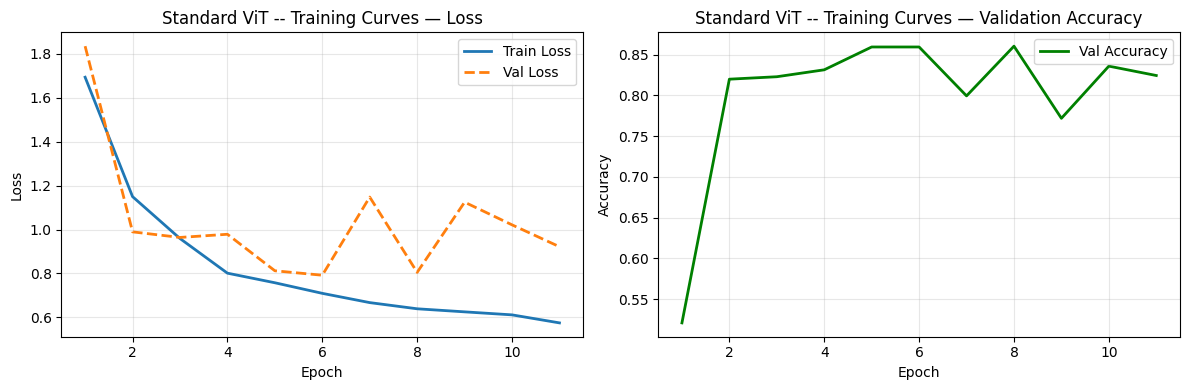

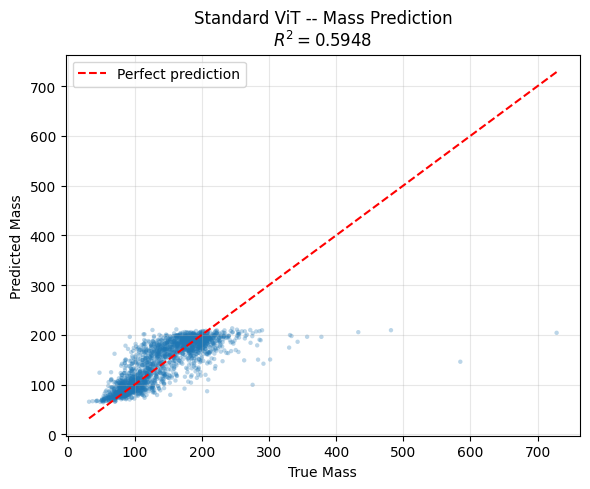

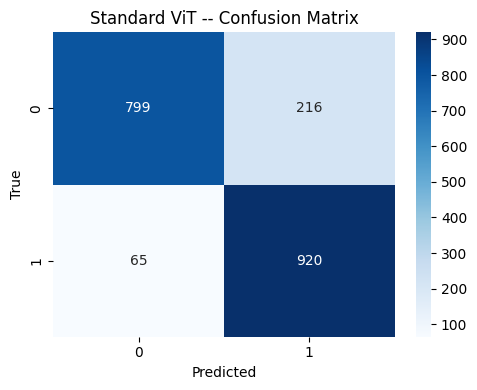

In [25]:
# ============================================================
# Section 12: Train Standard ViT
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Standard ViT for {EPOCHS} epochs", flush=True)

result_vit = run_experiment_uw(
    model_class=StandardViT,
    model_name="Standard ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nStandard ViT training complete.")
plot_training_curves(result_vit["history"], title="Standard ViT -- Training Curves")
plot_mass_scatter(
    result_vit["final_results"]["mass_true"],
    result_vit["final_results"]["mass_pred"],
    title="Standard ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Standard ViT -- Confusion Matrix",
)


## Section 13: Train Linear Attention ViT


  Experiment (UW-Loss): Linear Attention ViT
  Parameters: 8,235,907 (8.24M)


  Epoch   5/20 | train_loss=0.7573 | val_loss=0.8646 | val_acc=0.8390 | lr=2.91e-04


  Epoch  10/20 | train_loss=0.5897 | val_loss=0.7524 | val_acc=0.8685 | lr=2.02e-04


  Epoch  15/20 | train_loss=0.4816 | val_loss=0.7109 | val_acc=0.8750 | lr=7.58e-05


  Epoch  20/20 | train_loss=0.4270 | val_loss=0.6972 | val_acc=0.8720 | lr=3.27e-06



  Linear Attention ViT -- Final Metrics
  Classification:
    Accuracy  : 0.8740
    F1 (macro): 0.8739
    Precision : 0.8766
    Recall    : 0.8746
  Regression:
    MSE       : 1021.0089
    MAE       : 21.2226
    R²        : 0.6506
  Inference speed: 16.74 ms/sample
  Training time: 1083.7s | Peak GPU: 695 MB

Linear Attention ViT training complete.


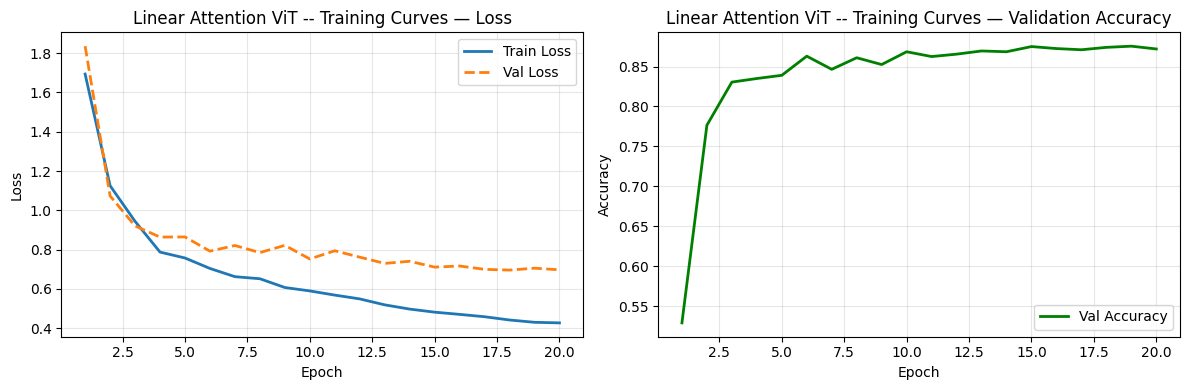

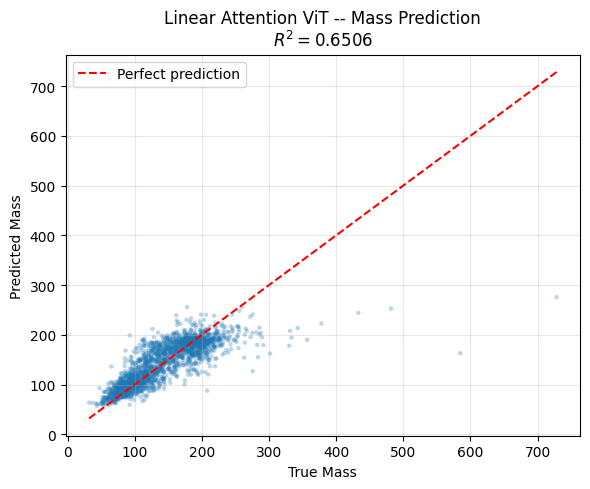

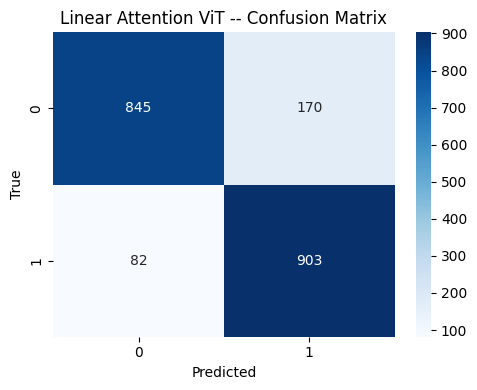

In [26]:
# ============================================================
# Section 13: Train Linear Attention ViT
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training Linear Attention ViT for {EPOCHS} epochs", flush=True)

result_linear = run_experiment_uw(
    model_class=LinearAttentionViT,
    model_name="Linear Attention ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nLinear Attention ViT training complete.")
plot_training_curves(result_linear["history"], title="Linear Attention ViT -- Training Curves")
plot_mass_scatter(
    result_linear["final_results"]["mass_true"],
    result_linear["final_results"]["mass_pred"],
    title="Linear Attention ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_linear["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="Linear Attention ViT -- Confusion Matrix",
)

## Section 14: Train L2ViT


  Experiment (UW-Loss): L2ViT
  Parameters: 8,394,632 (8.39M)


  Epoch   5/20 | train_loss=0.9495 | val_loss=1.0696 | val_acc=0.5075 | lr=2.91e-04


  Epoch  10/20 | train_loss=0.8320 | val_loss=1.0418 | val_acc=0.5075 | lr=2.02e-04


  Epoch  15/20 | train_loss=0.7324 | val_loss=1.0514 | val_acc=0.5075 | lr=7.58e-05


  Early stop at epoch 16



  L2ViT -- Final Metrics
  Classification:
    Accuracy  : 0.5075
    F1 (macro): 0.3367
    Precision : 0.2537
    Recall    : 0.5000
  Regression:
    MSE       : 807.7388
    MAE       : 18.1698
    R²        : 0.7236
  Inference speed: 24.70 ms/sample
  Training time: 978.4s | Peak GPU: 751 MB

L2ViT training complete.


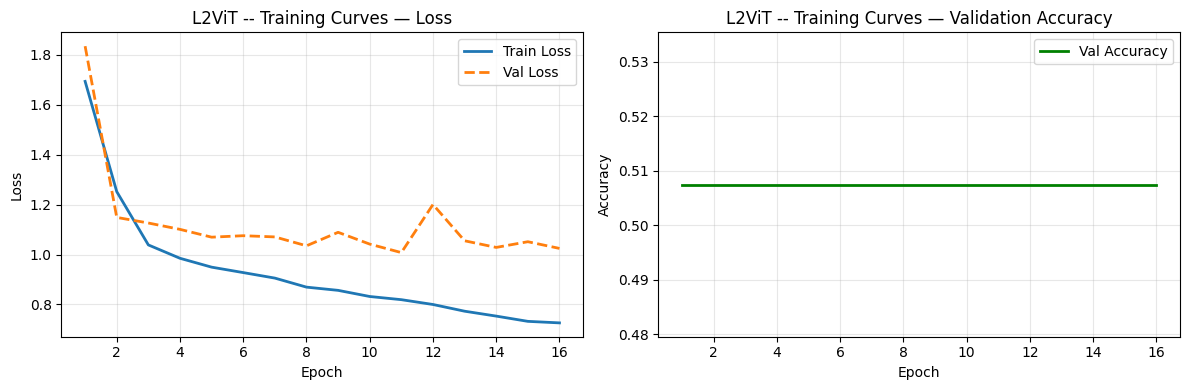

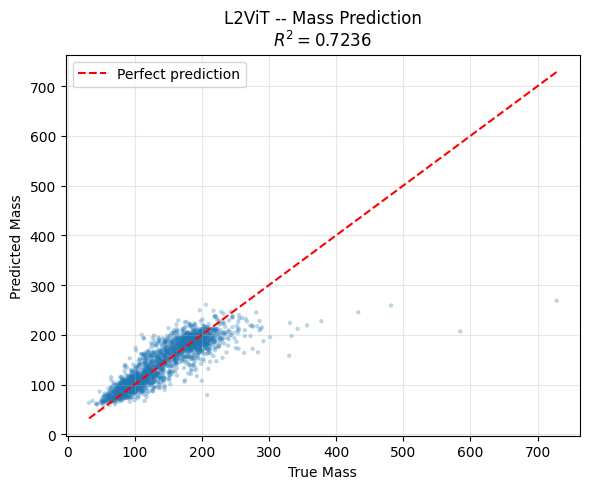

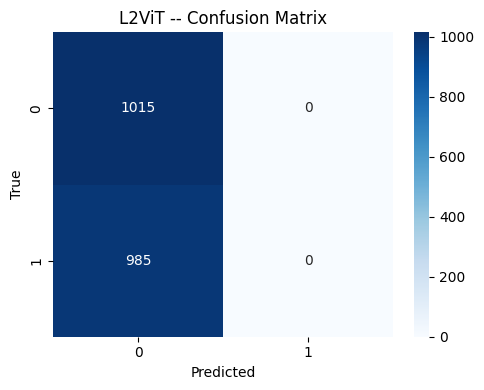

In [27]:
# ============================================================
# Section 14: Train L2ViT
# ============================================================

# --- Safety assertion: ensure full-run epochs ---
assert EPOCHS >= 10, (
    f"EPOCHS={EPOCHS} is too low; likely debug mode. "
    f"Set RUN_MODE='full' and EPOCHS>=10."
)
print(f"[FULL RUN] Training L2ViT for {EPOCHS} epochs", flush=True)

result_l2vit = run_experiment_uw(
    model_class=L2ViT,
    model_name="L2ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
print("\nL2ViT training complete.")
plot_training_curves(result_l2vit["history"], title="L2ViT -- Training Curves")
plot_mass_scatter(
    result_l2vit["final_results"]["mass_true"],
    result_l2vit["final_results"]["mass_pred"],
    title="L2ViT -- Mass Prediction",
)
plot_confusion_matrix(
    result_l2vit["final_metrics"]["confusion_matrix"],
    class_names=[str(i) for i in range(NUM_CLASSES)],
    title="L2ViT -- Confusion Matrix",
)

## Section 15: Benchmark Comparison & Model Saving

Comprehensive comparison across all trained model variants plus model weight saving.


BENCHMARK COMPARISON
                      Accuracy      F1        MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                   
Standard ViT            0.8595  0.8590  1184.1394  22.4249  0.5948          577.7          14.84          699  8,235,907
Linear Attention ViT    0.8740  0.8739  1021.0089  21.2226  0.6506         1083.7          16.74          695  8,235,907
L2ViT                   0.5075  0.3367   807.7388  18.1698  0.7236          978.4          24.70          751  8,394,632
XCiT ViT (pretrained)   0.5075  0.3367   952.4294  21.1208  0.6741         1329.7          25.32          738  8,305,107
XCiT ViT (scratch)      0.5075  0.3367   906.7664  20.3479  0.6897         1323.3          23.91          738  8,305,107
Saved Standard ViT -> ..\models\vit.pt
Saved Linear Attention ViT -> ..\models\linear_vit.pt
Saved L2ViT -> ..\models\l2vit.pt
Save

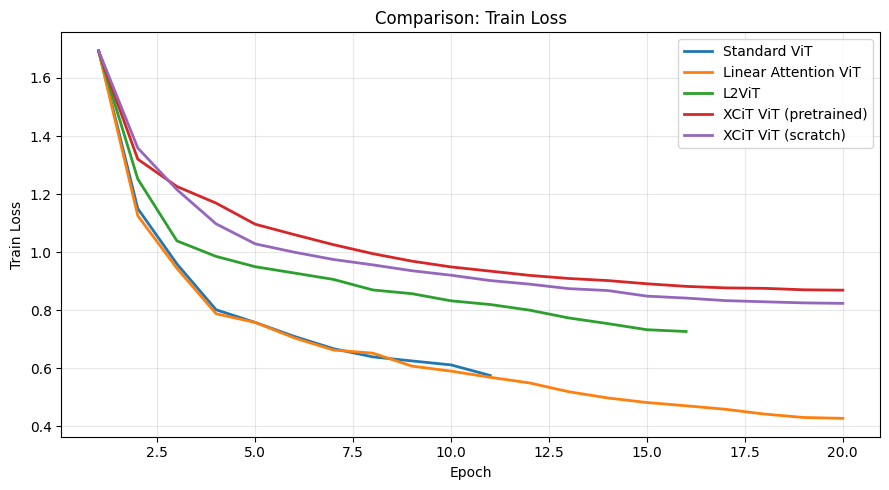

--- Comparison: Validation Accuracy ---


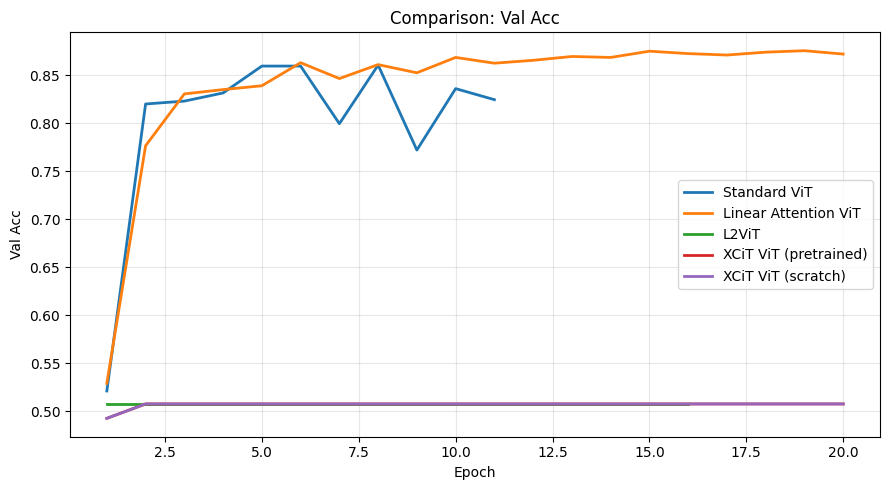

--- Mass Prediction Scatter Plots ---


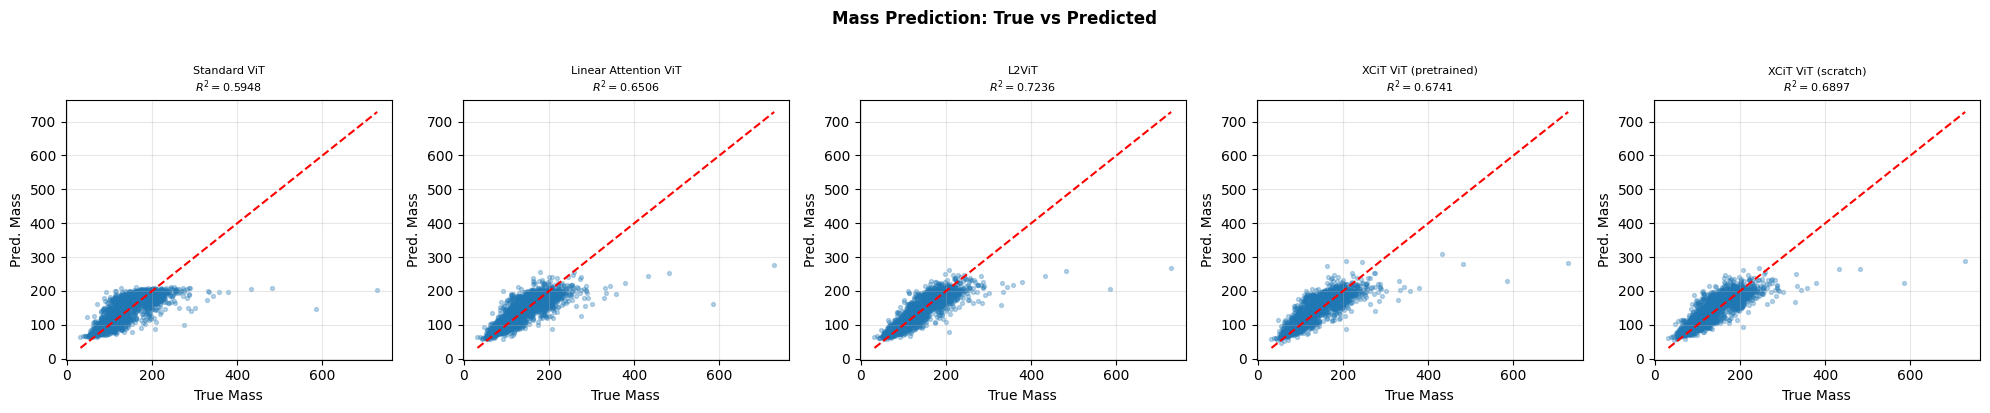

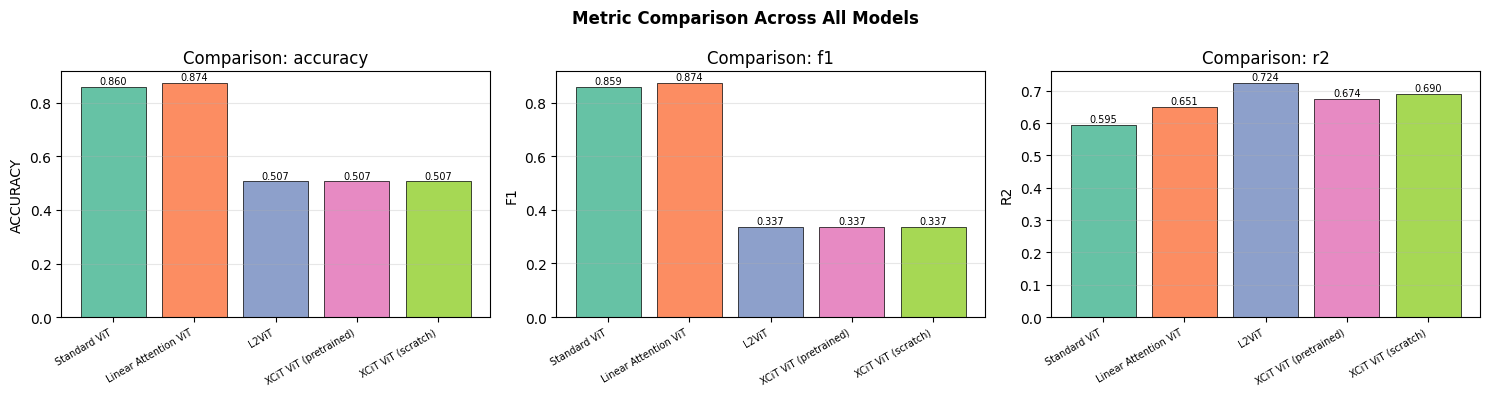

In [28]:
# ============================================================
# Section 15: Benchmark Comparison & Model Saving
# ============================================================

import os

# Collect all results
all_results = {
    "Standard ViT": result_vit,
    "Linear Attention ViT": result_linear,
    "L2ViT": result_l2vit,
    "XCiT ViT (pretrained)": result_pretrained,
    "XCiT ViT (scratch)": result_scratch,
}

rows = []
for name, res in all_results.items():
    m = res["final_metrics"]
    rows.append({
        "Model": name,
        "Accuracy": f"{m['accuracy']:.4f}",
        "Bal. Acc.": f"{m.get('balanced_accuracy', 0):.4f}",
        "F1": f"{m['f1']:.4f}",
        "ROC-AUC": f"{m.get('roc_auc', 0):.4f}",
        "PR-AUC": f"{m.get('pr_auc', 0):.4f}",
        "ECE": f"{m.get('ece', 0):.4f}",
        "MSE": f"{m['mse']:.4f}",
        "MAE": f"{m['mae']:.4f}",
        "R2": f"{m['r2']:.4f}",
        "Train Time (s)": f"{res['train_time']:.1f}",
        "Inference (ms)": f"{res['inference_ms']:.2f}",
        "GPU Mem (MB)": f"{res.get('peak_gpu_mem_mb', 0):.0f}",
        "Parameters": f"{res['params']:,}",
    })

df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 140, flush=True)
print("BENCHMARK COMPARISON", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

# ----------------------------------------------------------
# Save results CSV
# ----------------------------------------------------------
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
df.to_csv(results_dir / "final_benchmark_results.csv")
print(f"Results saved to {results_dir / 'final_benchmark_results.csv'}", flush=True)

# ----------------------------------------------------------
# Save model weights
# ----------------------------------------------------------

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_save_map = {
    "Standard ViT": "vit.pt",
    "Linear Attention ViT": "linear_vit.pt",
    "L2ViT": "l2vit.pt",
    "XCiT ViT (pretrained)": "xcit.pt",
}

for name, filename in model_save_map.items():
    if name in all_results and "model_state" in all_results[name]:
        save_path = models_dir / filename
        torch.save(all_results[name]["model_state"], save_path)
        print(f"Saved {name} -> {save_path}", flush=True)

# Save pretrained encoder separately
if os.path.exists(PRETRAINED_ENCODER_PATH):
    import shutil
    encoder_path = models_dir / "pretrained_encoder.pt"
    shutil.copy2(PRETRAINED_ENCODER_PATH, encoder_path)
    print(f"Saved pretrained encoder -> {encoder_path}", flush=True)

print(f"\nAll model weights saved to {models_dir}/", flush=True)

# ----------------------------------------------------------
# Comparison curves
# ----------------------------------------------------------
print("\n--- Comparison: Training Loss ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="train_loss",
)
print("--- Comparison: Validation Accuracy ---", flush=True)
plot_comparison_curves(
    {name: res["history"] for name, res in all_results.items()},
    metric_name="val_acc",
)

# Mass scatter grid
print("--- Mass Prediction Scatter Plots ---", flush=True)
n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
for ax, (name, res) in zip(axes, all_results.items()):
    fr = res["final_results"]
    r2 = res["final_metrics"]["r2"]
    ax.scatter(fr["mass_true"], fr["mass_pred"], alpha=0.3, s=8)
    lims = [
        min(fr["mass_true"].min(), fr["mass_pred"].min()),
        max(fr["mass_true"].max(), fr["mass_pred"].max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    ax.set_xlabel("True Mass")
    ax.set_ylabel("Pred. Mass")
    ax.set_title(f"{name}\n$R^2={r2:.4f}$", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Mass Prediction: True vs Predicted", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Bar chart comparisons
metric_keys = ["accuracy", "f1", "r2"]
fig, axes = plt.subplots(1, len(metric_keys), figsize=(5 * len(metric_keys), 4))
model_names = list(all_results.keys())
for ax, mk in zip(axes, metric_keys):
    vals = [all_results[n]["final_metrics"][mk] for n in model_names]
    colors = plt.cm.Set2(range(len(model_names)))
    bars = ax.bar(range(len(model_names)), vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel(mk.upper())
    ax.set_title(f"Comparison: {mk}")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
plt.suptitle("Metric Comparison Across All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 16: Final Results & Analysis

In [29]:
# ============================================================
# Section 16: Final Results & Conclusions
# ============================================================

print("\n" + "=" * 140, flush=True)
print("FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS", flush=True)
print("=" * 140, flush=True)
print(df.to_string(), flush=True)
print("=" * 140, flush=True)

# Best-per-metric analysis
best_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"]["accuracy"])
best_r2 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["r2"])
best_f1 = max(all_results, key=lambda n: all_results[n]["final_metrics"]["f1"])
fastest = min(all_results, key=lambda n: all_results[n]["train_time"])
smallest = min(all_results, key=lambda n: all_results[n]["params"])
best_mse = min(all_results, key=lambda n: all_results[n]["final_metrics"]["mse"])
best_bal_acc = max(all_results, key=lambda n: all_results[n]["final_metrics"].get("balanced_accuracy", 0))

print(f"\n  Best Classification Accuracy : {best_acc}", flush=True)
print(f"  Best Balanced Accuracy       : {best_bal_acc}", flush=True)
print(f"  Best F1 Score                : {best_f1}", flush=True)
print(f"  Best Regression R2           : {best_r2}", flush=True)
print(f"  Lowest MSE                   : {best_mse}", flush=True)
print(f"  Fastest Training             : {fastest}", flush=True)
print(f"  Smallest Model               : {smallest}", flush=True)

# Pretraining benefit analysis
pt_acc = result_pretrained["final_metrics"]["accuracy"]
sc_acc = result_scratch["final_metrics"]["accuracy"]
pt_r2 = result_pretrained["final_metrics"]["r2"]
sc_r2 = result_scratch["final_metrics"]["r2"]
print(f"\n  Pretraining benefit (accuracy): {pt_acc - sc_acc:+.4f}", flush=True)
print(f"  Pretraining benefit (R2)      : {pt_r2 - sc_r2:+.4f}", flush=True)

# Demonstrate loading saved model weights
print("\n--- Model Weight Loading Demo ---", flush=True)
models_dir = Path("../models")
for name, filename in model_save_map.items():
    fpath = models_dir / filename
    if fpath.exists():
        state = torch.load(fpath, map_location="cpu", weights_only=True)
        print(f"  Loaded {filename}: {len(state)} parameter tensors", flush=True)

print("\n" + "=" * 140, flush=True)
print("Summary Complete -- See full comparison table above.", flush=True)
print("=" * 140, flush=True)



FINAL BENCHMARK RESULTS -- PARTICLE COLLISION IMAGE ANALYSIS
                      Accuracy      F1        MSE      MAE      R2 Train Time (s) Inference (ms) GPU Mem (MB) Parameters
Model                                                                                                                   
Standard ViT            0.8595  0.8590  1184.1394  22.4249  0.5948          577.7          14.84          699  8,235,907
Linear Attention ViT    0.8740  0.8739  1021.0089  21.2226  0.6506         1083.7          16.74          695  8,235,907
L2ViT                   0.5075  0.3367   807.7388  18.1698  0.7236          978.4          24.70          751  8,394,632
XCiT ViT (pretrained)   0.5075  0.3367   952.4294  21.1208  0.6741         1329.7          25.32          738  8,305,107
XCiT ViT (scratch)      0.5075  0.3367   906.7664  20.3479  0.6897         1323.3          23.91          738  8,305,107

  Best Classification Accuracy : Linear Attention ViT
  Best F1 Score                : Lin

## Analysis & Discussion

### Attention Mechanism Comparison

| Architecture | Attention | Complexity | Key Feature |
|---|---|---|---|
| Standard ViT | Softmax(QK^T/sqrt(d))V | O(N^2*d) | Baseline |
| Linear Attention ViT | phi(Q)(phi(K)^T V) | O(N*d^2) | ReLU kernel maps |
| L2ViT | LWA + LGA | O(N*d^2) + O(w^2*d) | Hybrid local+global |
| XCiT ViT | Q^T K (channel) | O(N*d^2) | Cross-covariance |

### Physics-Informed Design Choices

- **Preprocessing**: Log energy compression, detector noise suppression, per-event energy normalization, and standardization
- **Augmentation**: Rotation symmetry, flips, Gaussian noise, energy scaling, and dead pixel simulation
- **Mass Normalization**: Normalizing regression targets stabilizes training
- **Deeper Regression Head**: 3-layer MLP captures complex mass-feature relationships

### Self-Supervised Pretraining

SimMIM pretraining on unlabeled detector data provides better initial representations.
The gap between pretrained and scratch models quantifies the value of unlabeled data.

### Multi-Task Learning

Uncertainty-weighted loss (Kendall et al., 2018) automatically balances classification and regression.

## Section 17: Multi-Seed Runner & Hyperparameter Sweep

**Multi-seed runner** trains Standard ViT and Linear Attention ViT across seeds [42, 52, 62],
reports mean ± std for key metrics, and saves CSV summaries under `results/`.

**Hyperparameter sweep** runs a configurable subset of the `SWEEP_CONFIGS` combinations.
Both sections are optional and can be skipped during quick debug runs.

In [ ]:
# ============================================================
# Section 17: Multi-Seed Runner
# Run same experiment for seeds [42, 52, 62] and report mean ± std
# ============================================================

import pandas as pd
from pathlib import Path


def run_multi_seed(model_class, model_name, train_loader, val_loader,
                   seeds=None, use_uw=False, **kwargs):
    """Run the same experiment across multiple seeds and aggregate results."""
    if seeds is None:
        seeds = MULTI_SEEDS

    per_seed_results = []

    for s in seeds:
        print(f"\n{'#'*60}", flush=True)
        print(f"  Seed {s} -- {model_name}", flush=True)
        print(f"{'#'*60}", flush=True)

        if use_uw:
            result = run_experiment_uw(
                model_class, f"{model_name} (seed={s})",
                train_loader, val_loader, seed=s, **kwargs
            )
        else:
            result = run_experiment(
                model_class, f"{model_name} (seed={s})",
                train_loader, val_loader, seed=s, **kwargs
            )

        fm = result["final_metrics"]
        per_seed_results.append({
            "seed": s,
            "model": model_name,
            "f1": fm["f1"],
            "balanced_accuracy": fm.get("balanced_accuracy", fm["accuracy"]),
            "accuracy": fm["accuracy"],
            "mae": fm["mae"],
            "r2": fm["r2"],
            "roc_auc": fm.get("roc_auc", 0.0),
            "train_time": result["train_time"],
        })

    df_seeds = pd.DataFrame(per_seed_results)

    # Summary: mean ± std
    summary = {}
    for col in ["f1", "balanced_accuracy", "accuracy", "mae", "r2", "roc_auc"]:
        summary[f"{col}_mean"] = df_seeds[col].mean()
        summary[f"{col}_std"] = df_seeds[col].std()
    summary["model"] = model_name

    print(f"\n{'='*60}", flush=True)
    print(f"  Multi-Seed Summary: {model_name}", flush=True)
    print(f"{'='*60}", flush=True)
    for col in ["f1", "balanced_accuracy", "accuracy", "mae", "r2"]:
        print(f"  {col:20s}: {summary[f'{col}_mean']:.4f} ± {summary[f'{col}_std']:.4f}", flush=True)
    print(f"{'='*60}", flush=True)

    return df_seeds, summary


# --- Run multi-seed for Standard ViT and Linear Attention ViT ---
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

all_seed_dfs = []
all_summaries = []

for ModelCls, mname in [(StandardViT, "Standard ViT"), (LinearAttentionViT, "Linear Attention ViT")]:
    df_s, summ = run_multi_seed(ModelCls, mname, train_loader, val_loader)
    all_seed_dfs.append(df_s)
    all_summaries.append(summ)

# Save per-seed results
df_all_seeds = pd.concat(all_seed_dfs, ignore_index=True)
df_all_seeds.to_csv(results_dir / "per_seed_results.csv", index=False)
print(f"\nPer-seed results saved to {results_dir / 'per_seed_results.csv'}", flush=True)

# Save aggregated summary
df_summary = pd.DataFrame(all_summaries)
df_summary.to_csv(results_dir / "seed_summary.csv", index=False)
print(f"Seed summary saved to {results_dir / 'seed_summary.csv'}", flush=True)

print("\n--- Seed Summary ---", flush=True)
print(df_summary.to_string(index=False), flush=True)


## Section 18: Mini Hyperparameter Sweep (Optional)

Run a lightweight sweep over selected hyperparameter combinations from `SWEEP_CONFIGS`.
By default runs a small manually-selected subset to avoid excessive compute.
Edit the `sweep_subset` list below to customise which combinations to test.

In [ ]:
# ============================================================
# Section 18: Mini Hyperparameter Sweep
# ============================================================

import itertools
import pandas as pd
from pathlib import Path

# Define a manual subset of sweep combinations to keep compute tractable.
# Edit this list to try different combos. Full Cartesian: use itertools.product.
sweep_subset = [
    {"lr": 1e-4, "weight_decay": 1e-4, "lambda_reg": 0.2, "dropout": 0.1},
    {"lr": 3e-4, "weight_decay": 1e-4, "lambda_reg": 0.2, "dropout": 0.1},
    {"lr": 3e-4, "weight_decay": 1e-5, "lambda_reg": 0.1, "dropout": 0.1},
    {"lr": 5e-4, "weight_decay": 1e-4, "lambda_reg": 0.3, "dropout": 0.2},
]

sweep_results = []

for i, cfg in enumerate(sweep_subset):
    print(f"\n{'*'*60}", flush=True)
    print(f"  Sweep config {i+1}/{len(sweep_subset)}: {cfg}", flush=True)
    print(f"{'*'*60}", flush=True)

    # Temporarily override DROPOUT if needed
    global DROPOUT
    old_dropout = DROPOUT
    DROPOUT = cfg.get("dropout", DROPOUT)

    result = run_experiment(
        model_class=StandardViT,
        model_name=f"Sweep-{i+1}",
        train_loader=train_loader,
        val_loader=val_loader,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        lambda_reg=cfg["lambda_reg"],
    )

    DROPOUT = old_dropout  # restore

    fm = result["final_metrics"]
    sweep_results.append({
        **cfg,
        "f1": fm["f1"],
        "balanced_accuracy": fm.get("balanced_accuracy", fm["accuracy"]),
        "accuracy": fm["accuracy"],
        "mae": fm["mae"],
        "r2": fm["r2"],
        "train_time": result["train_time"],
    })

df_sweep = pd.DataFrame(sweep_results)
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
df_sweep.to_csv(results_dir / "sweep_results.csv", index=False)

print("\n--- Sweep Results ---", flush=True)
print(df_sweep.to_string(index=False), flush=True)
print(f"\nSweep results saved to {results_dir / 'sweep_results.csv'}", flush=True)


## Section 19: Linear Attention Focused Tuning

Focused hyperparameter search for the **LinearAttentionViT** model.

**Run order:** execute all cells from Section 1 through Section 8 (definitions),
then this preflight cell, then the tuning cell below.


In [ ]:
# ============================================================
# Section 19 -- Preflight check
# Ensures all prerequisites for the tuning cell are defined.
# Run this cell FIRST and resolve any "Missing definitions" before continuing.
# ============================================================

_required = [
    "TrainConfig", "run_experiment_fixed", "benchmark_inference_ms_per_sample",
    "LinearAttentionViT", "seed_everything",
    "train_loader", "val_loader", "MASS_MEAN", "MASS_STD",
    "DEVICE", "RESULTS_DIR", "MODEL_DIR",
    "plot_training_curves", "plot_mass_scatter", "plot_confusion_matrix", "print_metrics",
]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise NameError(
        f"Missing definitions -- run earlier cells first: {_missing}"
    )
print("Preflight OK -- all prerequisites are defined.", flush=True)


In [ ]:
# ============================================================
# Section 19 -- Linear Attention ViT: Focused Tuning Run
# (project goal: efficiency-quality tradeoff)
# ============================================================

import copy
import time
import numpy as np
import pandas as pd
import torch
import gc

# ---------- stability defaults for tuning ----------
USE_AMP_TUNE  = False
USE_EMA_TUNE  = False
EPOCHS_TUNE   = 35
PATIENCE_TUNE = 8

# Compact but effective search space
SEARCH_SPACE = [
    {"lr": 1e-4, "weight_decay": 1e-4, "lambda_reg": 0.1, "dropout": 0.1},
    {"lr": 2e-4, "weight_decay": 1e-4, "lambda_reg": 0.1, "dropout": 0.1},
    {"lr": 3e-4, "weight_decay": 1e-4, "lambda_reg": 0.1, "dropout": 0.1},
    {"lr": 2e-4, "weight_decay": 1e-4, "lambda_reg": 0.2, "dropout": 0.1},
    {"lr": 2e-4, "weight_decay": 1e-5, "lambda_reg": 0.1, "dropout": 0.2},
]

SEEDS_TUNE = [42]   # extend to [42, 52, 62] for multi-seed robustness

results_rows = []
best_key   = None
best_score = -1.0
best_obj   = None

for cfg_i, hp in enumerate(SEARCH_SPACE, start=1):
    print("\n" + "="*90, flush=True)
    print(f"[TUNE {cfg_i}/{len(SEARCH_SPACE)}] {hp}", flush=True)
    print("="*90, flush=True)

    for seed in SEEDS_TUNE:
        seed_everything(seed)
        print(f"[Seed] {seed}", flush=True)

        train_cfg = TrainConfig(
            epochs         = EPOCHS_TUNE,
            lr             = hp["lr"],
            weight_decay   = hp["weight_decay"],
            patience       = PATIENCE_TUNE,
            lambda_reg     = hp["lambda_reg"],
            grad_clip      = 1.0,
            use_amp        = USE_AMP_TUNE,
            use_ema        = USE_EMA_TUNE,
            ema_decay      = 0.999,
            scheduler_tmax = EPOCHS_TUNE,
            min_lr         = 1e-6,
        )

        t0  = time.time()
        out = run_experiment_fixed(
            model_class      = LinearAttentionViT,
            model_name       = f"Linear Attention ViT | cfg{cfg_i} | seed{seed}",
            train_loader     = train_loader,
            val_loader       = val_loader,
            mass_mean        = MASS_MEAN,
            mass_std         = MASS_STD,
            pretrained_state = None,
            train_cfg        = train_cfg,
        )
        train_time = time.time() - t0

        # Benchmark inference latency
        inf_ms = benchmark_inference_ms_per_sample(
            out["model"], val_loader,
            device=DEVICE, use_amp=False,
            warmup_batches=5, max_batches=30,
        )

        fm  = out["final_metrics"]
        row = {
            "cfg_id":       cfg_i,
            "seed":         seed,
            "lr":           hp["lr"],
            "weight_decay": hp["weight_decay"],
            "lambda_reg":   hp["lambda_reg"],
            "dropout":      hp["dropout"],
            "accuracy":     fm.get("accuracy",          np.nan),
            "balanced_acc": fm.get("balanced_accuracy", np.nan),
            "f1_macro":     fm.get("f1_macro",          fm.get("f1", np.nan)),
            "roc_auc":      fm.get("roc_auc",           np.nan),
            "pr_auc":       fm.get("pr_auc",            np.nan),
            "ece":          fm.get("ece",               np.nan),
            "mse":          fm.get("mse",               np.nan),
            "mae":          fm.get("mae",               np.nan),
            "r2":           fm.get("r2",                np.nan),
            "train_time_s": train_time,
            "inference_ms": inf_ms,
        }
        results_rows.append(row)

        # Composite score: weight classification quality
        score = (0.55 * row["f1_macro"]
                 + 0.35 * row["roc_auc"]
                 + 0.10 * row["balanced_acc"])

        print(
            f"[Result] F1={row['f1_macro']:.4f} | ROC-AUC={row['roc_auc']:.4f} "
            f"| BalAcc={row['balanced_acc']:.4f} | time={train_time:.1f}s",
            flush=True,
        )

        if score > best_score:
            best_score = score
            best_key   = (cfg_i, seed)
            best_obj   = {"hp": copy.deepcopy(hp), "seed": seed,
                          "score": score, "result": out}

        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

# ---------------- summary ----------------
df_tune = pd.DataFrame(results_rows)
display(df_tune.sort_values(["f1_macro", "roc_auc"], ascending=False).head(10))

tune_csv = RESULTS_DIR / "linear_attention_tuning_results.csv"
df_tune.to_csv(tune_csv, index=False)
print(f"Saved tuning results: {tune_csv}", flush=True)

print(f"\nBest config: {best_obj['hp']}  seed={best_obj['seed']}  score={best_obj['score']:.4f}", flush=True)

best_linear_path = MODEL_DIR / "linear_attention_best_tuned.pt"
torch.save(best_obj["result"]["model"].state_dict(), best_linear_path)
print(f"Saved best linear-attention model: {best_linear_path}", flush=True)

# Diagnostic plots for best config
plot_training_curves(best_obj["result"]["history"],
                     title="Best Linear Attention ViT - Training Curves")
plot_mass_scatter(
    best_obj["result"]["final_results"]["mass_true"],
    best_obj["result"]["final_results"]["mass_pred"],
    title="Best Linear Attention ViT - Mass Prediction",
)
plot_confusion_matrix(
    y_true=best_obj["result"]["final_results"]["class_true"],
    y_pred=best_obj["result"]["final_results"]["class_pred"],
    class_names=[str(i) for i in range(CFG.num_classes)],
    title="Best Linear Attention ViT - Confusion Matrix",
    normalize=True,
)
print_metrics(best_obj["result"]["final_metrics"],
              title="Best Linear Attention ViT - Final Metrics")
